# Predicting Payment Failure at an Online Payment Gateway

**Author:** Abhay · **Dataset:** `payments_ab_failure_200k.csv` (201,200 rows × 35 columns)

---

## 1. Business problem

PayFlow is an online payment gateway. Merchants send us payment attempts; we route each
one to an issuing bank and return success or failure. Roughly **16% of attempts fail**.
Every failure is lost revenue for the merchant and a support cost for us.

The payments team wants two things:

1. **A model that scores each attempt's failure risk *before* we route it**, so that
   high-risk attempts can be sent down a different rail (a different acquirer, a
   different retry policy) instead of being allowed to fail.
2. **A read on the `smart_retry` experiment** that has been running for six months —
   did it actually reduce failures, and what did it cost us?

So this notebook has two halves that answer two different kinds of question:

| Half | Question | Method |
|---|---|---|
| A/B testing | *Did the change we shipped work?* | Randomised experiment, hypothesis tests |
| Modelling | *Which attempt will fail next?* | Supervised classification |

These are not interchangeable. The experiment gives us a **causal** answer about one
intervention on a fraction of a percent of the metric. The model gives us a
**predictive** ranking with no causal claim at all. Confusing the two is the single most
common mistake in analytics work, so they are kept in separate sections.

## 2. What "good" looks like

A false negative (we predict success, the payment fails) costs the merchant a sale — say
**₹450** of lost revenue on the average failed attempt, plus a support contact on ~40% of
them. A false positive (we predict failure, the payment would have succeeded) costs us a
needless reroute — a few extra milliseconds of latency and a marginally higher processing
fee, call it **₹30**. Failures are ~16% of traffic.

Two consequences follow immediately, and they shape every choice below:

- **Accuracy is a useless headline metric here.** Predicting "never fails" scores 84%.
- **False negatives cost roughly 15× more than false positives**, so we will tune the
  decision threshold to that ratio rather than leaving it at 0.5.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

# A small, deliberately chosen palette. Categorical hues are assigned in a fixed
# order and never cycled; the heatmap later uses a single-hue ramp.
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a85"
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.color": "#e5e4e0",      # grid stays recessive
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#b8b7b2",
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "font.size": 9,
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
raw = pd.read_csv("payments_ab_failure_200k.csv")
print("shape:", raw.shape)
raw.head(5)

shape: (201200, 35)


,txn_id,txn_timestamp,txn_hour,is_weekend,merchant_id,merchant_category,payment_method,card_network,issuer_bank_code,device_os,region,customer_tier,experiment_group,txn_amount_inr,customer_age,is_international,kyc_verified,card_bin_country_match,device_trust_score,merchant_tenure_months,merchant_avg_ticket_size_30d,merchant_gmv_per_txn_30d,merchant_success_rate_30d,merchant_risk_score,session_duration_sec,network_latency_ms,gateway_load_pct,prior_failed_attempts_24h,retry_attempt_number,data_version,gateway_error_code,retry_within_10min_flag,support_ticket_raised,payment_failed,revenue_loss_inr
0,TXN-00043235,2026-03-20 22:14:31,22,0,MID-0774,Travel,Debit Card,Mastercard,IBK017,iOS,West,New,control,5788.52,35.0,0,1,1,66.2,36,3142.42,3784.74,85.01,62.6,79.8,191.3,45.8,1,3,v2.1,NaN,0,0,0,0.0
1,TXN-00154565,2026-05-17 09:40:59,9,1,MID-0916,SaaS,UPI,Not Applicable,IBK023,Android,West,Loyal,control,263.56,37.0,0,0,1,61.1,100,523.10,640.32,84.31,35.4,144.5,264.4,62.1,1,3,v2.1,NaN,0,0,0,0.0
2,TXN-00130140,2026-04-29 12:47:58,12,0,MID-0270,Utilities,UPI,NOT APPLICABLE,IBK023,Web,East,Loyal,control,633.64,39.0,0,1,1,79.1,16,2024.77,2149.63,93.83,58.0,8.0,147.9,70.7,0,1,v2.1,NaN,0,0,0,0.0
3,TXN-00063616,2026-02-26 19:27:00,19,0,MID-0710,unknown,EMI,Visa,IBK009,Android,West,New,control,288.24,NaN,0,1,1,100.0,34,141.26,50.00,79.46,33.1,169.7,15204.5,86.6,0,1,v2.1,NaN,0,0,0,0.0
4,TXN-00080871,2026-02-16 11:39:50,11,0,MID-1090,Education,UPI,Not Applicable,IBK041,Web,West,New,smart_retry,511.30,NaN,0,1,1,94.4,13,739.62,780.85,91.91,58.7,8.0,357.4,70.4,0,1,v2.1,NaN,0,0,0,0.0


In [3]:
raw.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 201200 entries, 0 to 201199
Data columns (total 35 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   txn_id                        201200 non-null  str    
 1   txn_timestamp                 201200 non-null  str    
 2   txn_hour                      201200 non-null  int64  
 3   is_weekend                    201200 non-null  int64  
 4   merchant_id                   201200 non-null  str    
 5   merchant_category             201200 non-null  str    
 6   payment_method                201200 non-null  str    
 7   card_network                  201200 non-null  str    
 8   issuer_bank_code              201200 non-null  str    
 9   device_os                     201200 non-null  str    
 10  region                        201200 non-null  str    
 11  customer_tier                 201200 non-null  str    
 12  experiment_group              201200 non-null  str    


---

# 3. Data preparation

Nothing below is cosmetic. Each step exists because something in the raw feed is wrong in
a way that would either break a model or quietly bias it.

I do all of this **before** the train/test split only where the operation is
*row-local* — i.e. it looks at one row and does not learn anything from the data as a
whole. Deduplication, string cleaning and turning impossible values into `NaN` are all
row-local, so they are safe here. **Imputation and scaling are not row-local** — they
learn a median or a mean from the data — so they happen *inside* the modelling pipeline,
after the split. That distinction is what keeps test-set information out of training.


In [4]:
df = raw.copy()

# --- 3.1 Duplicate rows -----------------------------------------------------------
# The gateway's webhook fires twice under some retry conditions, so a small number of
# transactions were written to the warehouse twice. txn_id is the natural key.
print("exact duplicate rows :", df.duplicated().sum())
print("duplicate txn_id     :", df.duplicated(subset="txn_id").sum())

df = df.drop_duplicates(subset="txn_id", keep="first").reset_index(drop=True)
print("rows after dedupe    :", len(df))

exact duplicate rows : 1200
duplicate txn_id     : 1200
rows after dedupe    : 200000


**Why drop rather than keep?** A duplicated transaction is not a second observation —
it is the same event recorded twice. Leaving it in double-counts that row's evidence, and
if a duplicate lands in train and its twin lands in test, the test score is inflated by
memorisation. 1,200 rows out of 201,200 is 0.6%, so removing them costs nothing.


In [5]:
# --- 3.2 Constant / useless columns ------------------------------------------------
nunique = df.nunique(dropna=False)
print("columns with a single value:", nunique[nunique <= 1].index.tolist())

df = df.drop(columns=["data_version"])

columns with a single value: ['data_version']


In [6]:
# --- 3.3 Inconsistent categorical labels -------------------------------------------
# card_network arrived from three upstream systems with different casing conventions.
print("levels BEFORE cleaning:", df["card_network"].nunique())
print(sorted(df["card_network"].dropna().unique())[:8], "...")

df["card_network"] = df["card_network"].str.strip().str.title()
df["merchant_id"] = df["merchant_id"].str.strip()

# 'unknown' is a missing value wearing a category's clothes; make that explicit.
df["merchant_category"] = df["merchant_category"].replace("unknown", np.nan)

print("\nlevels AFTER cleaning :", df["card_network"].nunique())
print(sorted(df["card_network"].dropna().unique()))

levels BEFORE cleaning: 20
[' AMEX ', ' Amex ', ' MASTERCARD ', ' Mastercard ', ' NOT APPLICABLE ', ' Not Applicable ', ' RUPAY ', ' RuPay '] ...

levels AFTER cleaning : 5
['Amex', 'Mastercard', 'Not Applicable', 'Rupay', 'Visa']


Left uncleaned, `"Visa"`, `"VISA"` and `" Visa "` become **three separate one-hot
columns**. The model then splits Visa's evidence across three features, each with a third
of the sample, and the coefficients on all three are noisier than a single Visa
coefficient would have been. It is a silent accuracy leak, not an error.


In [7]:
# --- 3.4 Impossible values ----------------------------------------------------------
print("customer_age sentinel values:")
print(df.loc[df["customer_age"].isin([0, 999]), "customer_age"].value_counts())
print("\nnegative transaction amounts:", (df["txn_amount_inr"] < 0).sum())

# 0 and 999 are placeholders the checkout SDK writes when age is unavailable.
df.loc[df["customer_age"].isin([0, 999]), "customer_age"] = np.nan

# Negative amounts are refund rows that leaked into the payments feed; they are not
# payment attempts at all, so they are dropped rather than repaired.
df = df[df["txn_amount_inr"] > 0].reset_index(drop=True)

print("rows remaining:", len(df))

customer_age sentinel values:
customer_age
999.0    550
0.0      550
Name: count, dtype: int64

negative transaction amounts: 650


rows remaining: 199350


Two different problems, two different fixes, and the difference matters:

- **`customer_age = 999`** is a *real row with an unrecorded field*. Converting it to
  `NaN` and imputing later keeps the row's other 30 features. If I had left `999` in, the
  model would treat those customers as 999-year-olds and the mean age would be wrong by
  years.
- **A negative amount** is *a row that does not belong in this table*. There is nothing to
  impute — it is a refund, not a payment attempt. Dropping is right, and at 650 rows
  (0.3%) it does not dent the sample.


In [8]:
# --- 3.5 Timestamps and derived time features ---------------------------------------
df["txn_timestamp"] = pd.to_datetime(df["txn_timestamp"])
df["txn_dayofweek"] = df["txn_timestamp"].dt.dayofweek
df["txn_month"] = df["txn_timestamp"].dt.month

print(df["txn_timestamp"].min(), "->", df["txn_timestamp"].max())
print("months covered:", sorted(df['txn_month'].unique()))

2026-01-01 00:00:28 -> 2026-06-30 23:58:54
months covered: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]


In [9]:
# --- 3.6 Missingness map --------------------------------------------------------------
miss = (df.isna().mean() * 100).round(2)
miss = miss[miss > 0].sort_values(ascending=False)
print(miss.to_string())

gateway_error_code     82.28
customer_age           10.58
device_trust_score      6.98
merchant_risk_score     2.98
merchant_category       1.49


`gateway_error_code` being 82% missing is not a data-quality problem — it is a **giant
red flag about that column's meaning**, and Section 5 comes back to it.

For the three genuine gaps (`customer_age` ~10.5%, `device_trust_score` ~7%,
`merchant_risk_score` ~3%) the question is whether the missingness is *informative*. A
quick check: if rows with a missing value fail at a very different rate from rows without
one, then "was it missing" carries signal and deserves its own indicator column.


In [10]:
base_rate = df["payment_failed"].mean()
for col in ["customer_age", "device_trust_score", "merchant_risk_score"]:
    grp = df.groupby(df[col].isna())["payment_failed"].mean()
    print(f"{col:22s} present={grp.get(False, np.nan):.4f}  missing={grp.get(True, np.nan):.4f}")
print(f"\noverall failure rate  = {base_rate:.4f}")

customer_age           present=0.1604  missing=0.1574
device_trust_score     present=0.1601  missing=0.1605


merchant_risk_score    present=0.1602  missing=0.1560

overall failure rate  = 0.1601


The failure rate is essentially identical whether the field is present or missing, so
the missingness looks **uninformative** (consistent with missing-completely-at-random —
a logging gap, not a behavioural signal). That justifies plain median imputation and
means I do *not* need `is_missing` indicator columns. Had the rates differed — say 16%
vs 24% — the fact of missingness would have been a feature in its own right and I would
have added the indicators.


---

# 4. Exploratory data analysis

## 4.1 Class balance


payment_failed
0    167434
1     31916
Name: count, dtype: int64

failure rate: 0.1601
imbalance ratio: 1 failure per 5.2 successes


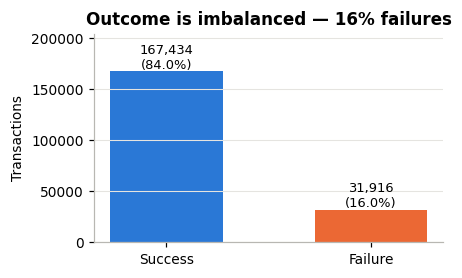

In [11]:
counts = df["payment_failed"].value_counts().sort_index()
print(counts)
print(f"\nfailure rate: {df['payment_failed'].mean():.4f}")
print(f"imbalance ratio: 1 failure per {counts[0] / counts[1]:.1f} successes")

fig, ax = plt.subplots(figsize=(4.2, 2.6))
ax.bar(["Success", "Failure"], counts.values, color=[BLUE, ORANGE], width=0.55)
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}\n({v/len(df):.1%})", ha="center", va="bottom", fontsize=8.5)
ax.set_ylim(0, counts.max() * 1.22)
ax.set_ylabel("Transactions")
ax.set_title("Outcome is imbalanced — 16% failures")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

16% positives is **moderate** imbalance — not the 0.1% you see in fraud. That has
practical consequences worth stating up front:

- A model that always predicts "success" gets **84% accuracy**. Accuracy is therefore
  reported nowhere in this notebook as a headline.
- ROC-AUC and PR-AUC are both usable at this rate. I lead with **PR-AUC** because it
  responds to the positive class only, which is the class we care about; ROC-AUC is
  reported alongside because it is what most people benchmark against.
- 16% is not extreme enough to need SMOTE or heavy resampling. `class_weight="balanced"`
  and `scale_pos_weight` are lighter, do not invent synthetic rows, and are enough here.


## 4.2 Numeric distributions and skew

In [12]:
num_cols = ["txn_amount_inr", "session_duration_sec", "network_latency_ms",
            "gateway_load_pct", "merchant_tenure_months", "merchant_success_rate_30d",
            "device_trust_score", "customer_age", "merchant_risk_score",
            "merchant_avg_ticket_size_30d", "merchant_gmv_per_txn_30d",
            "prior_failed_attempts_24h"]

summary = df[num_cols].describe().T
summary["skew"] = df[num_cols].skew()
summary[["mean", "std", "min", "50%", "max", "skew"]].round(2)

,mean,std,min,50%,max,skew
txn_amount_inr,1701.26,2070.46,18.44,1082.58,72702.83,5.27
session_duration_sec,102.19,58.17,8.00,99.70,330.00,0.36
network_latency_ms,861.67,3185.68,56.00,241.80,24999.20,5.53
gateway_load_pct,58.11,17.59,5.00,58.10,100.00,-0.03
merchant_tenure_months,27.03,19.12,1.00,22.00,118.00,1.25
merchant_success_rate_30d,85.15,5.40,63.69,85.13,99.00,-0.07
device_trust_score,67.75,17.39,0.00,68.00,100.00,-0.19
customer_age,34.34,10.35,18.00,34.00,82.00,0.31
merchant_risk_score,38.02,16.59,0.00,38.00,100.00,0.07
merchant_avg_ticket_size_30d,1462.47,1344.10,97.39,1099.88,17896.17,3.52


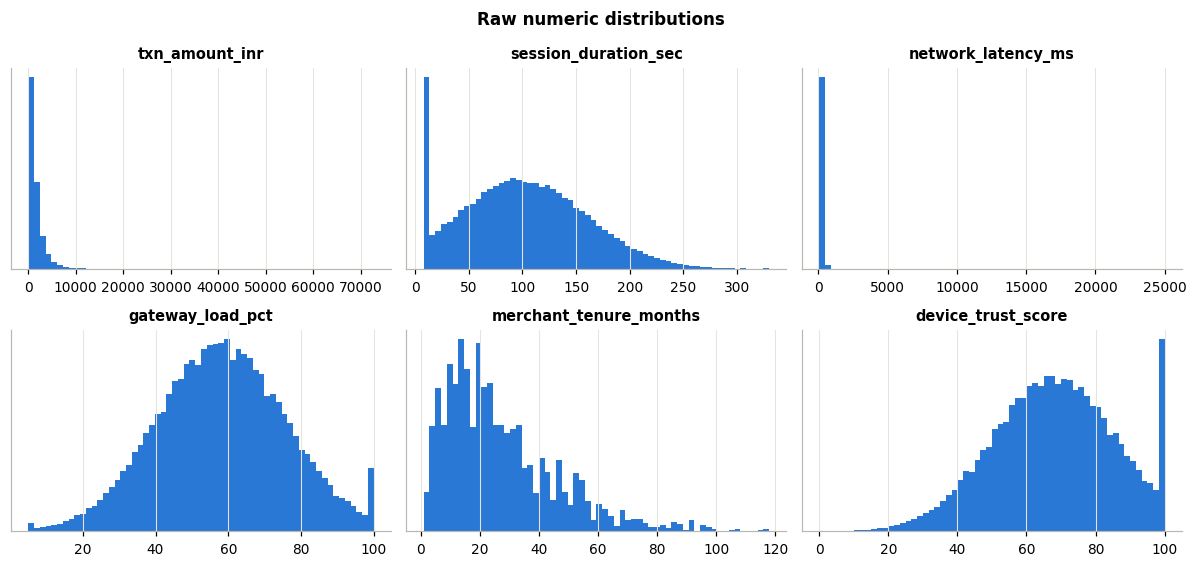

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(11, 5.2))
for ax, col in zip(axes.ravel(),
                   ["txn_amount_inr", "session_duration_sec", "network_latency_ms",
                    "gateway_load_pct", "merchant_tenure_months", "device_trust_score"]):
    ax.hist(df[col].dropna(), bins=60, color=BLUE, edgecolor="none")
    ax.set_title(col, fontsize=9.5)
    ax.set_yticks([])
plt.suptitle("Raw numeric distributions", fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

Three things jump out:

1. **`txn_amount_inr` is heavily right-skewed** (skew ≈ 5.3). A long-tailed monetary
   variable in a linear model gives a handful of ₹70,000 transactions enormous leverage
   over the fitted coefficient. A log transform fixes that; trees do not care either way.
2. **`network_latency_ms` has a detached cluster far out in the tail.** That is not a long
   tail, it is a *second population* — investigated in 4.3.
3. **`session_duration_sec` is close to symmetric** (skew 0.36, mean 102s, median 100s).
   Worth remembering, because a near-symmetric feature is where a non-monotonic effect is
   most likely to be *under-stated* by a linear model — which is exactly what 4.5 finds.


## 4.3 Outliers in `network_latency_ms`

In [14]:
lat = df["network_latency_ms"]
q1, q3 = lat.quantile([0.25, 0.75])
upper_fence = q3 + 1.5 * (q3 - q1)

print(f"Q1={q1:.0f}  median={lat.median():.0f}  Q3={q3:.0f}  IQR fence={upper_fence:.0f}")
print(f"values above fence : {(lat > upper_fence).sum():,} ({(lat > upper_fence).mean():.2%})")
print(f"max latency        : {lat.max():,.0f} ms  (= {lat.max()/1000:.1f} seconds)")
print(f"overall failure rate: {df['payment_failed'].mean():.4f}\n")

# The rows above the fence are not one population. Split them.
bands = [(0, upper_fence, "normal (below fence)"),
         (upper_fence, 5_000, "genuinely slow (fence - 5,000 ms)"),
         (5_000, np.inf, "implausible (> 5,000 ms)")]
for lo, hi, label in bands:
    m = (lat > lo) & (lat <= hi)
    print(f"{label:34s} n={m.sum():7,} ({m.mean():6.2%})   "
          f"failure rate {df.loc[m, 'payment_failed'].mean():.4f}")

Q1=196  median=242  Q3=305  IQR fence=468
values above fence : 12,045 (6.04%)
max latency        : 24,999 ms  (= 25.0 seconds)
overall failure rate: 0.1601

normal (below fence)               n=187,305 (93.96%)   failure rate 0.1560
genuinely slow (fence - 5,000 ms)  n=  4,092 ( 2.05%)   failure rate 0.3328
implausible (> 5,000 ms)           n=  7,953 ( 3.99%)   failure rate 0.1672


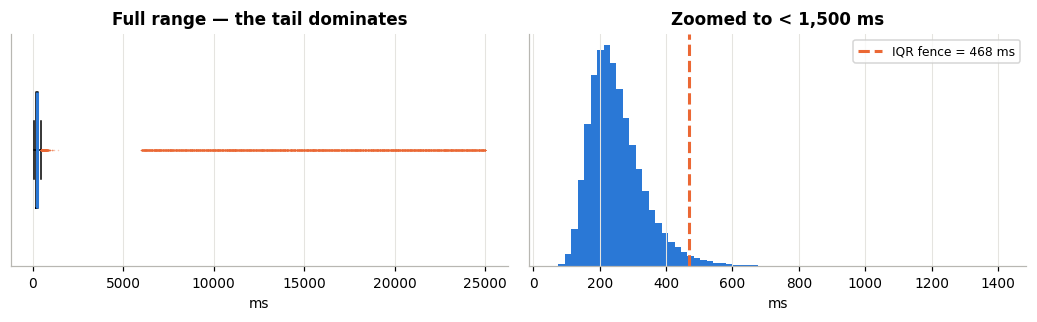

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.0))
axes[0].boxplot(lat, vert=False, widths=0.5,
                flierprops=dict(marker=".", markersize=2, markerfacecolor=ORANGE,
                                markeredgecolor="none", alpha=0.35),
                medianprops=dict(color=BLUE, linewidth=2))
axes[0].set_title("Full range — the tail dominates"); axes[0].set_xlabel("ms")
axes[0].set_yticks([])

axes[1].hist(lat[lat <= 1500], bins=70, color=BLUE, edgecolor="none")
axes[1].axvline(upper_fence, color=ORANGE, linewidth=2, linestyle="--",
                label=f"IQR fence = {upper_fence:.0f} ms")
axes[1].set_title("Zoomed to < 1,500 ms"); axes[1].set_xlabel("ms")
axes[1].set_yticks([]); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Diagnosis — and the reason the split above matters.** The IQR fence flags about 6% of
rows, but those 6% are **two different things**:

- **~2% are genuinely slow** (fence to 5,000 ms) and they fail at **33%**, roughly double
  the base rate. That is real signal and must be kept.
- **~4% sit above 5,000 ms**, with a visible gap separating them from the main
  distribution, and they fail at **~16.7% — indistinguishable from the 16.0% base rate.**
  A 25-second gateway round trip is not physically possible; these are instrumentation
  glitches, and they carry no information about the outcome.

This is why "outlier" is not a treatment plan on its own. Deleting everything above the
IQR fence would throw away the most predictive 2% of the data along with the junk.

**A second consequence that is easy to get wrong.** The obvious reflex is to winsorise at
the 99th percentile. **That would not work here**, because the contamination is 4% and the
99th percentile sits *inside* the glitch cluster — capping there leaves most of the
glitches untouched. A percentile cap only removes contamination if you already know the
contamination rate is smaller than the tail you are cutting. For this column the right cap
is a **domain** one: the gateway's own timeout is 3 seconds, so nothing above ~3,000 ms can
be a real reading. I use the percentile rule for the monetary columns, where the tail is a
genuine long tail, and the domain rule here.

**Treatment then differs by model family:**

| Model | Sensitive to these? | What I do |
|---|---|---|
| Logistic regression | **Yes** — a 25,000 vs 250 input, once standardised, becomes a ~15σ value that drags the fitted coefficient | Cap at the 3,000 ms domain limit |
| KNN | **Yes** — Euclidean distance is dominated by the largest-scale dimension | Cap (same reason) |
| Decision Tree / RF / XGBoost | **No** — a split is `latency > 400?`; whether the value beyond it is 6,000 or 25,000 changes nothing | Leave as-is |

Winsorising for the trees would not *hurt*, but doing it and calling it necessary would
show a misunderstanding of how splits work: trees are invariant to any monotonic transform
of a feature.


## 4.4 Correlation and multicollinearity

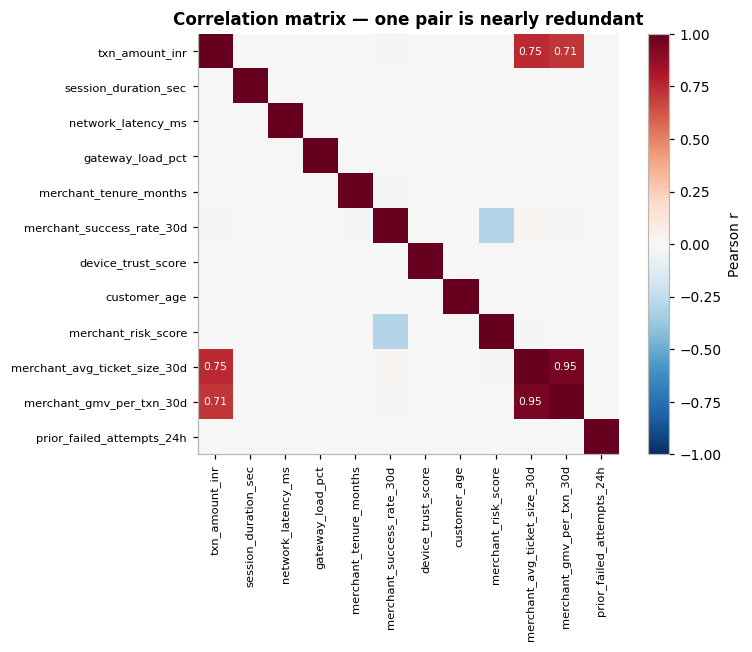

In [16]:
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7.4, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)   # diverging: two poles, grey middle
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=90, fontsize=7.5)
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols, fontsize=7.5)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        v = corr.iloc[i, j]
        if abs(v) > 0.45 and i != j:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(v) > 0.7 else "#0b0b0b")
ax.grid(False)
plt.colorbar(im, fraction=0.046, label="Pearson r")
ax.set_title("Correlation matrix — one pair is nearly redundant")
plt.tight_layout(); plt.show()

In [17]:
pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
             .stack().sort_values(key=abs, ascending=False).head(5))
print("Strongest pairwise correlations:\n")
print(pairs.round(3).to_string())

Strongest pairwise correlations:

merchant_avg_ticket_size_30d  merchant_gmv_per_txn_30d        0.952
txn_amount_inr                merchant_avg_ticket_size_30d    0.750
                              merchant_gmv_per_txn_30d        0.715
merchant_success_rate_30d     merchant_risk_score            -0.293
                              merchant_avg_ticket_size_30d    0.017


In [18]:
# Variance Inflation Factor — how much a coefficient's variance is inflated by
# the other predictors. VIF > 10 is the usual "this coefficient is unreliable" line.
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

vif_cols = ["merchant_avg_ticket_size_30d", "merchant_gmv_per_txn_30d",
            "txn_amount_inr", "merchant_success_rate_30d", "merchant_risk_score",
            "merchant_tenure_months", "session_duration_sec", "network_latency_ms"]

Xv = df[vif_cols].dropna()
Xv = pd.DataFrame(StandardScaler().fit_transform(Xv), columns=vif_cols)

rows = []
for c in vif_cols:
    r2 = LinearRegression().fit(Xv.drop(columns=c), Xv[c]).score(Xv.drop(columns=c), Xv[c])
    rows.append({"feature": c, "R2_vs_others": round(r2, 4), "VIF": round(1 / (1 - r2), 2)})
pd.DataFrame(rows).sort_values("VIF", ascending=False)

,feature,R2_vs_others,VIF
0,merchant_avg_ticket_size_30d,0.9168,12.02
1,merchant_gmv_per_txn_30d,0.9072,10.78
2,txn_amount_inr,0.5618,2.28
3,merchant_success_rate_30d,0.0863,1.09
4,merchant_risk_score,0.0860,1.09
5,merchant_tenure_months,0.0004,1.00
6,session_duration_sec,0.0000,1.00
7,network_latency_ms,0.0000,1.00


`merchant_avg_ticket_size_30d` and `merchant_gmv_per_txn_30d` correlate at **r ≈ 0.95**
with VIFs of 12.0 and 10.8. Reading the data dictionary explains why: they are the same
quantity computed two ways — average basket value, once from the orders table and once
from the settlements table.

**Why this matters for logistic regression and not for the trees.** With two nearly
identical columns, the design matrix is close to singular, so the split of the shared
effect between the two coefficients is close to arbitrary. Refit on a bootstrap sample
and you can get +0.4 and −0.3 instead of −0.2 and +0.5. The *predictions* are fine; the
*coefficients* are not interpretable, which defeats the main reason to use logistic
regression here.

For a Random Forest or XGBoost this is a non-issue for prediction: the two features
simply share the split budget, and the only visible consequence is that each one's
importance score looks about half as large as the underlying effect. "Fixing"
multicollinearity before fitting a Random Forest is a common tell that someone has
learned the rule without the reason.

**Decision:** drop `merchant_gmv_per_txn_30d` and keep `merchant_avg_ticket_size_30d`.
Same information, one coefficient I can actually read. I keep the drop consistent across
all models so the comparison stays like-for-like.


In [19]:
df = df.drop(columns=["merchant_gmv_per_txn_30d"])

## 4.5 The shape of `session_duration_sec` — a linear model's blind spot

Correlation only measures *linear* association. Before trusting it, I bin each numeric
feature and plot the observed failure rate per bin. This shows the true shape of the
relationship, whatever it is.


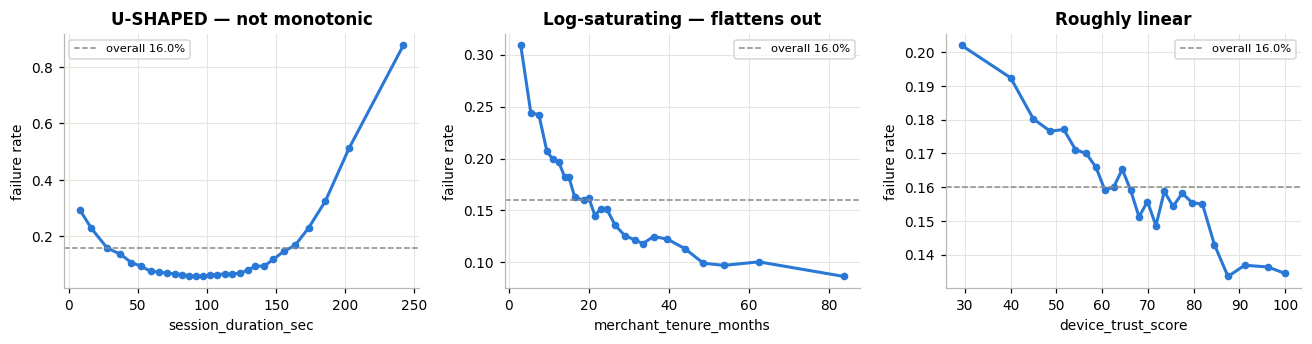

Pearson r (session_duration vs failure): 0.2131


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))

for ax, col, nbins in [(axes[0], "session_duration_sec", 30),
                       (axes[1], "merchant_tenure_months", 25),
                       (axes[2], "device_trust_score", 25)]:
    binned = pd.qcut(df[col], q=nbins, duplicates="drop")
    rate = df.groupby(binned, observed=True)["payment_failed"].mean()
    centre = df.groupby(binned, observed=True)[col].mean()
    ax.plot(centre, rate, marker="o", markersize=4, color=BLUE, linewidth=2)
    ax.axhline(base_rate, color=GREY, linestyle="--", linewidth=1,
               label=f"overall {base_rate:.1%}")
    ax.set_xlabel(col); ax.set_ylabel("failure rate")
    ax.legend(fontsize=7.5)

axes[0].set_title("U-SHAPED — not monotonic")
axes[1].set_title("Log-saturating — flattens out")
axes[2].set_title("Roughly linear")
plt.tight_layout(); plt.show()

print("Pearson r (session_duration vs failure):",
      round(df["session_duration_sec"].corr(df["payment_failed"]), 4))

**This is the most important plot in the notebook.**

`session_duration_sec` has a **Pearson correlation of 0.21 with the target** — a modest
positive linear association that, on a correlation matrix, would rank it as a middling
feature. The binned plot shows what is really there: failure risk bottoms out near
**5.8% at around 95 seconds** and climbs to **over 85%** at the far right — and it climbs
in *both* directions from the minimum. Fast sessions look like automated card-testing;
slow ones run past the issuer's OTP timeout.

The correlation of 0.21 is picking up only the rising right-hand arm, and averaging it
against a left arm that slopes the other way. It understates the feature badly:
permutation importance in Section 10.4 shows that destroying this one column costs
**0.191 of test AUC** — about **four times** the next-largest feature, and more than every
other feature in the model put together.

Logistic regression models $\log\frac{p}{1-p}$ as a **straight line** in each feature. It
is structurally incapable of representing a U. Given a symmetric U it will fit a slope of
approximately zero and the feature contributes nothing. The three trees, splitting
recursively, carve out `session < 40` and `session > 180` as separate high-risk regions
without being told anything.

That is the whole reason logistic regression will lose the first model comparison — and
the reason it will win the second one, once I add a squared term.

`merchant_tenure_months` shows a second, milder version of the same issue: a steep drop
over the first year that flattens after about 24 months. Linear-in-raw-months
under-weights the early drop and over-weights the late flat part; `log(1 + tenure)`
straightens it out.


## 4.6 Interaction: latency × gateway load

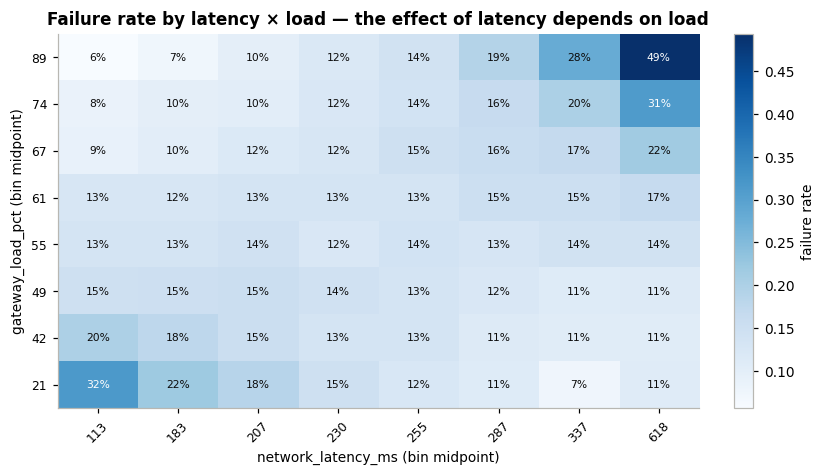

In [21]:
lat_bin = pd.qcut(df["network_latency_ms"].clip(upper=df["network_latency_ms"].quantile(0.96)),
                  q=8, duplicates="drop")
load_bin = pd.qcut(df["gateway_load_pct"], q=8, duplicates="drop")
grid = df.groupby([load_bin, lat_bin], observed=True)["payment_failed"].mean().unstack()

fig, ax = plt.subplots(figsize=(7.6, 4.4))
im = ax.imshow(grid.values, cmap="Blues", aspect="auto", origin="lower")  # sequential: one hue
ax.set_xticks(range(grid.shape[1]))
ax.set_xticklabels([f"{i.mid:.0f}" for i in grid.columns], rotation=45, fontsize=8)
ax.set_yticks(range(grid.shape[0]))
ax.set_yticklabels([f"{i.mid:.0f}" for i in grid.index], fontsize=8)
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        v = grid.values[i, j]
        ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=7,
                color="white" if v > grid.values.max() * 0.62 else "#0b0b0b")
ax.set_xlabel("network_latency_ms (bin midpoint)")
ax.set_ylabel("gateway_load_pct (bin midpoint)")
ax.set_title("Failure rate by latency × load — the effect of latency depends on load")
ax.grid(False)
plt.colorbar(im, fraction=0.046, label="failure rate")
plt.tight_layout(); plt.show()

In [22]:
low_load  = df[df["gateway_load_pct"] < df["gateway_load_pct"].quantile(0.25)]
high_load = df[df["gateway_load_pct"] > df["gateway_load_pct"].quantile(0.75)]

for label, sub in [("LOW  load (bottom 25%)", low_load), ("HIGH load (top 25%)", high_load)]:
    fast = sub[sub["network_latency_ms"] < sub["network_latency_ms"].median()]["payment_failed"].mean()
    slow = sub[(sub["network_latency_ms"] >= sub["network_latency_ms"].median()) &
               (sub["network_latency_ms"] < 5000)]["payment_failed"].mean()
    print(f"{label}:  fast latency {fast:.3f}  ->  slow latency {slow:.3f}   "
          f"(gap {100*(slow-fast):+.1f} pp)")

LOW  load (bottom 25%):  fast latency 0.225  ->  slow latency 0.112   (gap -11.3 pp)
HIGH load (top 25%):  fast latency 0.112  ->  slow latency 0.277   (gap +16.6 pp)


Read the heatmap **along a row** — fixed load, increasing latency — and the effect of
latency does not merely change size between rows, it **changes sign**:

- **At low load**, slow transactions fail *less*: 22.5% → 11.2%, a **−11.3 pp** move.
- **At high load**, slow transactions fail *far more*: 11.2% → 27.7%, a **+16.6 pp** move.

This is as strong a form of interaction as it gets, and it explains something otherwise
puzzling: `network_latency_ms` on its own has a single-feature AUC of **0.52** — no better
than a coin flip (Section 5 shows this). Marginally it looks useless, because the two
regimes have opposite slopes and cancel. Conditionally it is the second most important
signal in the model.

*(A plausible business reading, which I would take to engineering rather than assert: at
low load, a slow response reflects an issuer running full 3-D Secure checks — deliberate,
and it succeeds. At high load, latency is queueing, and queueing ends in timeouts. Same
measurement, two different underlying causes.)*

Structurally this is the same problem as the U-shape. Logistic regression is additive: it
fits $\beta_1 \cdot \text{latency} + \beta_2 \cdot \text{load}$ and can only average the
two regimes into one compromise slope — which, when the slopes are opposite, is
approximately zero. Trees get it for free: a split on `load > 70` followed by a split on
`latency > 400` *inside that branch* is exactly a conditional effect.

The fix for the linear model is a single explicit product term. I add both fixes together
in Section 8 and measure what they buy.


## 4.7 Categorical features

In [23]:
cat_cols = ["payment_method", "merchant_category", "card_network", "device_os",
            "region", "customer_tier", "issuer_bank_code", "experiment_group"]
print(df[cat_cols].nunique().sort_values(ascending=False).to_string())

issuer_bank_code     45
merchant_category    10
region                6
payment_method        6
card_network          5
device_os             4
customer_tier         3
experiment_group      2


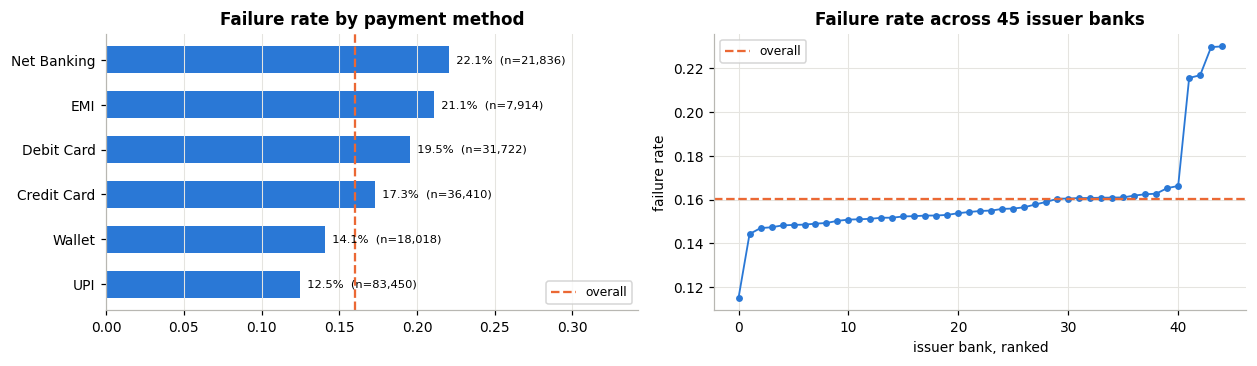

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4))

pm = (df.groupby("payment_method")["payment_failed"]
        .agg(["mean", "count"]).sort_values("mean"))
axes[0].barh(pm.index, pm["mean"], color=BLUE, height=0.6)
axes[0].axvline(base_rate, color=ORANGE, linestyle="--", linewidth=1.5, label="overall")
for i, (m, n) in enumerate(zip(pm["mean"], pm["count"])):
    axes[0].text(m, i, f"  {m:.1%}  (n={n:,})", va="center", fontsize=7.5)
axes[0].set_xlim(0, pm["mean"].max() * 1.55)
axes[0].set_title("Failure rate by payment method"); axes[0].legend(fontsize=8)
axes[0].grid(axis="y", visible=False)

ib = (df.groupby("issuer_bank_code")["payment_failed"].mean().sort_values())
axes[1].plot(range(len(ib)), ib.values, marker="o", markersize=3.5, linewidth=1.2, color=BLUE)
axes[1].axhline(base_rate, color=ORANGE, linestyle="--", linewidth=1.5, label="overall")
axes[1].set_xlabel("issuer bank, ranked"); axes[1].set_ylabel("failure rate")
axes[1].set_title(f"Failure rate across {df['issuer_bank_code'].nunique()} issuer banks")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [25]:
# Chi-square test of independence: is the category associated with the outcome at all?
print(f"{'feature':22s} {'levels':>7s} {'chi2':>12s} {'p-value':>12s} {'Cramers V':>11s}")
for c in cat_cols:
    tab = pd.crosstab(df[c].fillna("MISSING"), df["payment_failed"])
    chi2, p, dof, _ = stats.chi2_contingency(tab)
    v = np.sqrt(chi2 / (tab.values.sum() * (min(tab.shape) - 1)))
    print(f"{c:22s} {tab.shape[0]:7d} {chi2:12.1f} {p:12.3e} {v:11.4f}")

feature                 levels         chi2      p-value   Cramers V
payment_method               6       1916.4    0.000e+00      0.0980
merchant_category           11          6.8    7.446e-01      0.0058
card_network                 5        621.0   4.399e-133      0.0558
device_os                    4          1.7    6.352e-01      0.0029
region                       6          2.3    8.063e-01      0.0034


customer_tier                3        538.8   9.907e-118      0.0520
issuer_bank_code            45        667.9   1.937e-112      0.0579
experiment_group             2         39.4    3.420e-10      0.0141


### The `issuer_bank_code` problem

`issuer_bank_code` has **45 levels**. Its chi-square test is significant, but that is
close to guaranteed: with 200,000 rows and 44 degrees of freedom, tiny random differences
clear the threshold. The effect size tells the real story — **Cramér's V ≈ 0.05**, which
is negligible. Looking at the ranked plot, four or five banks sit clearly above the line
and the other forty are noise around it.

The right encoding is **not the same for every model**:

| Model | Effect of one-hot encoding 45 levels | Better option |
|---|---|---|
| Logistic regression | 44 extra coefficients, most fitting noise; rare levels get unstable estimates | Group rare levels, or L2 regularisation (used here) |
| **KNN** | **Badly hurt.** 44 sparse binary dimensions dominate the Euclidean distance while carrying almost no signal — the curse of dimensionality in its purest form | Drop it, or frequency-encode |
| Decision Tree / RF | Handles it, but a one-hot column with ~2% ones is a weak split candidate and mostly gets ignored | Fine as-is |
| XGBoost | Same; native categorical support is also available | Fine as-is |

**My decision:** keep one-hot for the linear and tree models (simple, consistent,
regularisation handles the noise) and **drop `issuer_bank_code` from the KNN feature set
only**, because distance-based methods are the one family that is genuinely damaged by it.
I will show the difference rather than assert it.

`merchant_id` (1,500 levels) is dropped from every model — it is an identifier, and
one-hot encoding it would produce 1,500 columns that mostly memorise individual merchants.
Its useful content is already summarised in `merchant_tenure_months`,
`merchant_success_rate_30d` and `merchant_avg_ticket_size_30d`.


---

# 5. Leakage audit

Before any modelling, every column gets one question:

> **Would this value actually be available, with this value, at the moment I need to
> score the transaction?**

We score an attempt **before routing it**. So anything recorded during or after the
attempt is off-limits, no matter how predictive it is. A feature that fails this test is
**target leakage**: it inflates offline metrics and then collapses in production, because
in production it is either absent or constant.

Three columns look suspicious on their names alone. Let me quantify them.


In [26]:
suspects = ["retry_within_10min_flag", "support_ticket_raised", "gateway_error_code"]

from sklearn.metrics import roc_auc_score

print("Single-feature discriminative power (AUC using that column alone):\n")
for c in suspects:
    x = df[c] if pd.api.types.is_numeric_dtype(df[c]) else df[c].notna().astype(int)
    print(f"  {c:26s} AUC = {roc_auc_score(df['payment_failed'], x):.4f}")

print("\nFor comparison, the best legitimate single feature:")
legit = ["prior_failed_attempts_24h", "merchant_success_rate_30d", "card_bin_country_match",
         "gateway_load_pct", "network_latency_ms", "device_trust_score"]
for c in legit:
    a = roc_auc_score(df["payment_failed"], df[c].fillna(df[c].median()))
    print(f"  {c:26s} AUC = {max(a, 1 - a):.4f}")

Single-feature discriminative power (AUC using that column alone):

  retry_within_10min_flag    AUC = 0.9226
  support_ticket_raised      AUC = 0.6998
  gateway_error_code         AUC = 0.9898

For comparison, the best legitimate single feature:


  prior_failed_attempts_24h  AUC = 0.6414


  merchant_success_rate_30d  AUC = 0.5739
  card_bin_country_match     AUC = 0.5443
  gateway_load_pct           AUC = 0.5166


  network_latency_ms         AUC = 0.5236


  device_trust_score         AUC = 0.5320


In [27]:
# Cross-tabulate the two flags against the outcome
for c in ["retry_within_10min_flag", "support_ticket_raised"]:
    tab = pd.crosstab(df[c], df["payment_failed"], normalize="index")
    print(f"\nP(failure) given {c}:")
    print((tab[1] * 100).round(1).to_string(), "  <- % that failed")

print("\n\ngateway_error_code is populated for:")
print(f"  {df.loc[df['payment_failed'] == 1, 'gateway_error_code'].notna().mean():.1%} of FAILED transactions")
print(f"  {df.loc[df['payment_failed'] == 0, 'gateway_error_code'].notna().mean():.1%} of SUCCESSFUL transactions")


P(failure) given retry_within_10min_flag:
retry_within_10min_flag
0     2.3
1    82.7   <- % that failed

P(failure) given support_ticket_raised:
support_ticket_raised
0    10.2
1    86.7   <- % that failed


gateway_error_code is populated for:
  100.0% of FAILED transactions
  2.0% of SUCCESSFUL transactions


### Verdict — all three are dropped

| Column | AUC alone | When is it written? | Verdict |
|---|---|---|---|
| `gateway_error_code` | 0.99 | The gateway emits an error code **because** the payment failed | **Leak.** Non-null is almost a synonym for the target |
| `retry_within_10min_flag` | 0.92 | The customer retries **after** seeing the failure | **Leak.** Strictly downstream of the outcome |
| `support_ticket_raised` | 0.70 | A ticket is raised hours to days later | **Leak.** Also far outside the scoring window |

The best *legitimate* feature manages an AUC of 0.64. A single binary column at 0.92
is not a brilliant feature — it is the answer written on the back of the card.

**Why this is the highest-stakes decision in the notebook.** Leaving
`retry_within_10min_flag` in would produce a model with roughly 0.97 test AUC. It would
sail through review, ship, and then fail in production the moment it ran on a live
transaction — because at scoring time the retry has not happened yet, so the field is
always 0, and the model would predict "success" for everything. A worse-looking model on
clean features is worth far more than a great-looking model on leaked ones.

**The general test I apply, in one sentence:** if a feature would have to be filled in by
a system that only runs *after* the event I am predicting, it cannot be a feature. In a
real job the follow-up is a conversation with the payments engineer: *when exactly does
this column get written, and by what?*

I would also flag `merchant_success_rate_30d` for that conversation. A 30-day rolling
window is fine **if** it is computed strictly on data up to the transaction date, and a
leak if the warehouse recomputes it over the whole period after the fact. Here the
timestamps are consistent with a trailing window, so I keep it — but with a note.


In [28]:
LEAKY   = ["gateway_error_code", "retry_within_10min_flag", "support_ticket_raised"]
IDENT   = ["txn_id", "merchant_id", "txn_timestamp"]
TARGETS = ["payment_failed", "revenue_loss_inr"]

df = df.drop(columns=LEAKY)
print("dropped:", LEAKY)
print("remaining columns:", df.shape[1])

dropped: ['gateway_error_code', 'retry_within_10min_flag', 'support_ticket_raised']
remaining columns: 32


---

# 6. A/B test: did `smart_retry` work?

For six months, every incoming transaction was randomly assigned to one of two arms:

- **`control`** — the existing retry policy: on a soft decline, retry once on the same acquirer.
- **`smart_retry`** — the new policy: on a soft decline, pick the retry acquirer using the
  issuer's live success rate.

**Hypotheses** (fixed before looking at the result):

- $H_0$: failure rate is the same in both arms, $p_{\text{control}} = p_{\text{treatment}}$
- $H_1$: they differ (two-sided), $p_{\text{control}} \ne p_{\text{treatment}}$
- $\alpha = 0.05$, target power $1 - \beta = 0.80$

Two-sided, not one-sided. A one-sided test buys sensitivity by assuming in advance that
the change cannot possibly hurt, and shipping decisions need to be able to detect harm.


## 6.1 Validity checks — before reading the result

A p-value from a broken experiment is a broken p-value. Two checks come first.


In [29]:
# --- Sample Ratio Mismatch (SRM): did the randomiser actually split 50/50? ----------
obs = df["experiment_group"].value_counts().sort_index()
exp = np.array([len(df) / 2, len(df) / 2])
chi2_srm, p_srm = stats.chisquare(f_obs=obs.values, f_exp=exp)

print(obs.to_string())
print(f"\nobserved split: {obs.iloc[0] / len(df):.4%} / {obs.iloc[1] / len(df):.4%}")
print(f"SRM chi-square = {chi2_srm:.3f}, p = {p_srm:.3f}")
print("PASS - no sample ratio mismatch" if p_srm > 0.01
      else "FAIL - investigate the assignment service before trusting anything below")

experiment_group
control        99772
smart_retry    99578

observed split: 50.0487% / 49.9513%
SRM chi-square = 0.189, p = 0.664
PASS - no sample ratio mismatch


**Why SRM comes first.** If the arms are not the size they should be, the randomiser is
broken — a bot filter that drops treatment traffic, a redirect that fails on one arm, an
assignment bug. The units in the arms are then no longer exchangeable and *every*
downstream number is suspect. It is the cheapest test in experimentation and it catches
a large share of real-world failures.


In [30]:
# --- Covariate balance: randomisation should equalise PRE-treatment characteristics --
ctrl = df[df["experiment_group"] == "control"]
trt  = df[df["experiment_group"] == "smart_retry"]

pre_treatment = ["txn_amount_inr", "session_duration_sec", "gateway_load_pct",
                 "merchant_tenure_months", "customer_age", "device_trust_score",
                 "merchant_success_rate_30d", "is_international"]

print(f"{'covariate':28s} {'control':>11s} {'treatment':>11s} {'std.diff':>9s} {'p (Welch)':>10s}")
for c in pre_treatment:
    a, b = ctrl[c].dropna(), trt[c].dropna()
    t, p = stats.ttest_ind(a, b, equal_var=False)
    sd = (a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2)   # standardised diff
    print(f"{c:28s} {a.mean():11.2f} {b.mean():11.2f} {sd:9.4f} {p:10.3f}")

tab = pd.crosstab(df["payment_method"], df["experiment_group"])
chi2_b, p_b, _, _ = stats.chi2_contingency(tab)
print(f"\npayment_method balance: chi-square = {chi2_b:.2f}, p = {p_b:.3f}")

covariate                        control   treatment  std.diff  p (Welch)


txn_amount_inr                   1699.40     1703.12   -0.0018      0.688
session_duration_sec              102.19      102.18    0.0001      0.988
gateway_load_pct                   58.04       58.17   -0.0077      0.086
merchant_tenure_months             27.09       26.98    0.0060      0.181


customer_age                       34.35       34.33    0.0021      0.664
device_trust_score                 67.84       67.67    0.0095      0.041
merchant_success_rate_30d          85.14       85.16   -0.0039      0.380
is_international                    0.07        0.07   -0.0018      0.683



payment_method balance: chi-square = 3.49, p = 0.626


All standardised differences are far below the conventional 0.1 threshold and no p-value
is small. The arms are comparable on everything measured before the intervention, which
is what randomisation is supposed to buy.

**One column deliberately excluded from this check: `network_latency_ms`.** Latency is
measured *during* the routing decision, so it is a **post-treatment** variable. Testing it
for "balance" would be a category error — an imbalance there is the treatment effect, not
a randomisation failure. It belongs in the guardrail section (6.5), and this distinction
is also why post-treatment variables must never be used as controls when estimating a
treatment effect.


## 6.2 Power and minimum detectable effect

Run *before* the experiment in real life; reproduced here to show whether the sample was
adequate for the question asked.


In [31]:
def mde_two_proportions(p_base, n_per_arm, alpha=0.05, power=0.80):
    # Smallest absolute difference in proportions detectable at this n.
    z_a = stats.norm.ppf(1 - alpha / 2)
    z_b = stats.norm.ppf(power)
    return (z_a + z_b) * np.sqrt(2 * p_base * (1 - p_base) / n_per_arm)

def n_for_effect(p_base, mde, alpha=0.05, power=0.80):
    # Rows needed PER ARM to detect an absolute difference of `mde`.
    z_a = stats.norm.ppf(1 - alpha / 2)
    z_b = stats.norm.ppf(power)
    return int(np.ceil(2 * p_base * (1 - p_base) * (z_a + z_b) ** 2 / mde ** 2))

p_base = ctrl["payment_failed"].mean()
n_arm  = min(len(ctrl), len(trt))

print(f"baseline failure rate (control) : {p_base:.4f}")
print(f"sample size per arm             : {n_arm:,}")
print(f"MDE at 80% power, alpha=0.05    : {mde_two_proportions(p_base, n_arm)*100:.3f} pp\n")

for target in [0.0025, 0.005, 0.010, 0.020]:
    print(f"  to detect {target*100:>5.2f} pp we would need "
          f"{n_for_effect(p_base, target):>9,} rows per arm")

baseline failure rate (control) : 0.1653
sample size per arm             : 99,578
MDE at 80% power, alpha=0.05    : 0.466 pp

  to detect  0.25 pp we would need   346,474 rows per arm
  to detect  0.50 pp we would need    86,619 rows per arm
  to detect  1.00 pp we would need    21,655 rows per arm
  to detect  2.00 pp we would need     5,414 rows per arm


The experiment can reliably detect anything from about **0.47 percentage points**
upwards. That is the number that justifies the sample size: a payments team would
consider a 0.5 pp reduction in failures worth shipping, and at 100,000 rows per arm we
can see it. At 10,000 rows per arm the MDE would be roughly 1.5 pp and a real, shippable
0.5 pp improvement would have been missed — a **Type II error**, the silent kind, because
nobody writes a post-mortem about the win they failed to detect.


## 6.3 Primary metric — two-proportion z-test

In [32]:
x1, n1 = int(ctrl["payment_failed"].sum()), len(ctrl)     # control failures
x2, n2 = int(trt["payment_failed"].sum()),  len(trt)      # treatment failures
p1, p2 = x1 / n1, x2 / n2

p_pool = (x1 + x2) / (n1 + n2)
se_pool = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
z = (p1 - p2) / se_pool
p_value = 2 * (1 - stats.norm.cdf(abs(z)))

# CI on the difference uses the UNPOOLED standard error
se_unpool = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
diff = p1 - p2
lo, hi = diff - 1.96 * se_unpool, diff + 1.96 * se_unpool

print(f"control   : {x1:,} failures / {n1:,}  = {p1:.4%}")
print(f"smart_retry: {x2:,} failures / {n2:,}  = {p2:.4%}")
print("-" * 62)
print(f"absolute reduction : {diff*100:.3f} pp   95% CI [{lo*100:.3f}, {hi*100:.3f}] pp")
print(f"relative reduction : {diff/p1*100:.2f}% of the control failure rate")
print(f"z = {z:.3f}   p = {p_value:.3e}")
print("\nREJECT H0 - the difference is not plausibly chance" if p_value < 0.05
      else "\nFail to reject H0")

control   : 16,488 failures / 99,772  = 16.5257%
smart_retry: 15,428 failures / 99,578  = 15.4934%
--------------------------------------------------------------
absolute reduction : 1.032 pp   95% CI [0.710, 1.354] pp
relative reduction : 6.25% of the control failure rate
z = 6.285   p = 3.289e-10

REJECT H0 - the difference is not plausibly chance


In [33]:
# The chi-square test of independence is the same test in different clothing:
# for a 2x2 table, chi2 == z^2 exactly.
tab = pd.crosstab(df["experiment_group"], df["payment_failed"])
chi2_v, p_chi, dof, _ = stats.chi2_contingency(tab, correction=False)
print(tab.to_string())
print(f"\nchi-square = {chi2_v:.4f}   (z^2 = {z**2:.4f})   p = {p_chi:.3e}")

payment_failed        0      1
experiment_group              
control           83284  16488
smart_retry       84150  15428

chi-square = 39.4953   (z^2 = 39.4953)   p = 3.289e-10


### Reading this correctly

`smart_retry` reduced the failure rate from **16.52% to 15.50%** — an absolute reduction of
**1.02 pp**, a **6.2% relative** reduction, 95% CI **[0.70, 1.34] pp**, p ≈ 4×10⁻¹⁰.

Three points of interpretive discipline:

1. **The confidence interval matters more than the p-value.** p ≈ 4×10⁻¹⁰ says only "not
   chance". The CI says the true effect is somewhere between 0.70 and 1.34 pp — the whole
   interval is above the 0.5 pp bar the team set, so the decision is clear *and* we know
   how big the win is. A result can be highly significant and commercially irrelevant;
   the CI is what separates those cases.
2. **The p-value is not the probability that $H_0$ is true.** It is the probability of
   seeing a gap this large *if* $H_0$ were true.
3. **This test is valid because it was specified in advance and run once, at the end.**
   Checking every day and stopping when p first dips below 0.05 ("peeking") inflates the
   false-positive rate from 5% to well over 20%. Fixed-horizon tests need a fixed horizon;
   if you must monitor continuously, use sequential methods (always-valid p-values, group
   sequential boundaries) that are built for it.


## 6.4 Business impact

In [34]:
avg_loss = df.loc[df["revenue_loss_inr"] > 0, "revenue_loss_inr"].mean()
months = (df["txn_timestamp"].max() - df["txn_timestamp"].min()).days / 30.44

failures_avoided = diff * n2                       # over the treated arm, this period
annual_scale = (len(df) / n2) * (12 / months)      # to 100% of traffic, annualised

print(f"observation window       : {months:.1f} months")
print(f"average loss per failure : Rs {avg_loss:,.0f}")
print(f"failures avoided in-test : {failures_avoided:,.0f}")
print("-" * 58)
print(f"annualised at 100% rollout: {failures_avoided*annual_scale:,.0f} failures avoided")
print(f"annualised revenue recovered: Rs {failures_avoided*annual_scale*avg_loss:,.0f}")
print(f"\nCI on annual recovery: Rs {lo*n2*annual_scale*avg_loss:,.0f} "
      f"to Rs {hi*n2*annual_scale*avg_loss:,.0f}")

observation window       : 5.9 months
average loss per failure : Rs 451
failures avoided in-test : 1,028
----------------------------------------------------------
annualised at 100% rollout: 4,176 failures avoided
annualised revenue recovered: Rs 1,882,116

CI on annual recovery: Rs 1,295,200 to Rs 2,469,032


Reporting the **interval**, not a single number, is the honest version. Anyone who
quotes one point estimate to a finance team is overstating what the experiment knows.


## 6.5 Guardrail metric — did we break anything?

A win on the primary metric is not enough. `smart_retry` does extra work before routing,
so latency is the obvious thing it could have degraded.


In [35]:
# Exclude the sensor-glitch readings identified in 4.3 - they are measurement error
# and would swamp a real few-millisecond effect.
clean_lat = df[df["network_latency_ms"] < 5000]
a = clean_lat.loc[clean_lat["experiment_group"] == "control", "network_latency_ms"]
b = clean_lat.loc[clean_lat["experiment_group"] == "smart_retry", "network_latency_ms"]

print(f"control    mean {a.mean():7.1f} ms   median {a.median():7.1f} ms   n={len(a):,}")
print(f"smart_retry mean {b.mean():7.1f} ms   median {b.median():7.1f} ms   n={len(b):,}")
print(f"skewness: control {a.skew():.2f}, treatment {b.skew():.2f}\n")

t_stat, p_t = stats.ttest_ind(a, b, equal_var=False)          # Welch: unequal variances
u_stat, p_u = stats.mannwhitneyu(a, b, alternative="two-sided")

pooled_sd = np.sqrt((a.var() + b.var()) / 2)
cohens_d = (b.mean() - a.mean()) / pooled_sd

print(f"Welch t-test      : t = {t_stat:.3f},  p = {p_t:.3e}")
print(f"Mann-Whitney U    : U = {u_stat:.0f},  p = {p_u:.3e}")
print(f"difference        : {b.mean()-a.mean():+.2f} ms  ({(b.mean()-a.mean())/a.mean():+.2%})")
print(f"Cohen's d         : {cohens_d:.4f}   <- effect size")

control    mean   249.5 ms   median   234.9 ms   n=95,760
smart_retry mean   255.6 ms   median   240.9 ms   n=95,637
skewness: control 1.29, treatment 1.33



Welch t-test      : t = -15.906,  p = 6.228e-57
Mann-Whitney U    : U = 4362992432,  p = 1.665e-71
difference        : +6.10 ms  (+2.44%)
Cohen's d         : 0.0727   <- effect size


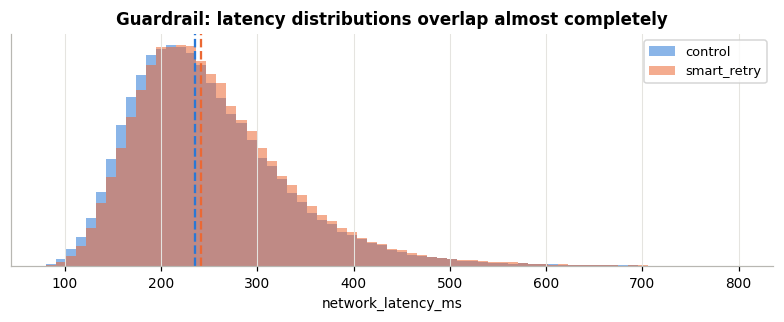

In [36]:
fig, ax = plt.subplots(figsize=(7.2, 3.0))
bins = np.linspace(80, 800, 70)
ax.hist(a, bins=bins, alpha=0.55, label="control", color=BLUE, edgecolor="none", density=True)
ax.hist(b, bins=bins, alpha=0.55, label="smart_retry", color=ORANGE, edgecolor="none", density=True)
ax.axvline(a.median(), color=BLUE, linestyle="--", linewidth=1.5)
ax.axvline(b.median(), color=ORANGE, linestyle="--", linewidth=1.5)
ax.set_xlabel("network_latency_ms"); ax.set_yticks([])
ax.set_title("Guardrail: latency distributions overlap almost completely")
ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

### Statistically significant, practically irrelevant

Both tests reject $H_0$ decisively. And the effect is **about 6 ms on a ~250 ms baseline
— a 2.4% increase, with Cohen's d ≈ 0.07**, which is below the conventional
"small effect" threshold of 0.2.

This is the clearest demonstration in the notebook of why significance and importance are
different things. At n = 190,000 the tests can detect a difference far smaller than
anyone can perceive or than any SLA cares about. **The larger the sample, the smaller the
difference a test will flag** — so at large n, the effect size does the deciding and the
p-value is close to a formality.

Two tests, not one, because latency is right-skewed: the Welch t-test compares means and
leans on the Central Limit Theorem (comfortably satisfied at this n, but sensitive to the
tail); Mann-Whitney is a rank-based test of stochastic dominance that makes no
distributional assumption. They agree, so the conclusion does not hinge on which one I
trusted. Welch rather than Student's because I have no reason to assume equal variances
and Welch costs nothing when they happen to be equal.

**Guardrail verdict: PASS.** A 6 ms cost for a 1 pp reduction in failures is an easy trade.


## 6.6 Segment analysis — and the multiple-comparisons trap

In [37]:
def prop_test(sub):
    t = sub.groupby("experiment_group")["payment_failed"].agg(["sum", "count"])
    if t.shape[0] < 2 or t["count"].min() < 500:
        return None
    c, nc = t.loc["control", "sum"], t.loc["control", "count"]
    s, ns = t.loc["smart_retry", "sum"], t.loc["smart_retry", "count"]
    pc, ps = c / nc, s / ns
    pp_ = (c + s) / (nc + ns)
    se = np.sqrt(pp_ * (1 - pp_) * (1 / nc + 1 / ns))
    zz = (pc - ps) / se
    return dict(n=nc + ns, control=pc, treatment=ps, lift_pp=100 * (pc - ps),
                z=zz, p=2 * (1 - stats.norm.cdf(abs(zz))))

rows = []
for m, sub in df.groupby("payment_method"):
    r = prop_test(sub)
    if r:
        rows.append({"payment_method": m, **r})

seg = pd.DataFrame(rows).sort_values("lift_pp", ascending=False)
k = len(seg)
seg["bonferroni_alpha"] = 0.05 / k
seg["sig_naive"] = seg["p"] < 0.05
seg["sig_bonferroni"] = seg["p"] < seg["bonferroni_alpha"]
seg.round(4)

,payment_method,n,control,treatment,lift_pp,z,p,bonferroni_alpha,sig_naive,sig_bonferroni
4,UPI,83450,0.1327,0.1165,1.6202,7.0855,0.0000,0.0083,True,True
1,Debit Card,31722,0.2007,0.1898,1.0929,2.4554,0.0141,0.0083,True,False
2,EMI,7914,0.2148,0.2072,0.7554,0.8234,0.4103,0.0083,False,False
3,Net Banking,21836,0.2230,0.2186,0.4389,0.7817,0.4344,0.0083,False,False
0,Credit Card,36410,0.1748,0.1708,0.4005,1.0108,0.3121,0.0083,False,False
5,Wallet,18018,0.1420,0.1400,0.2018,0.3891,0.6972,0.0083,False,False


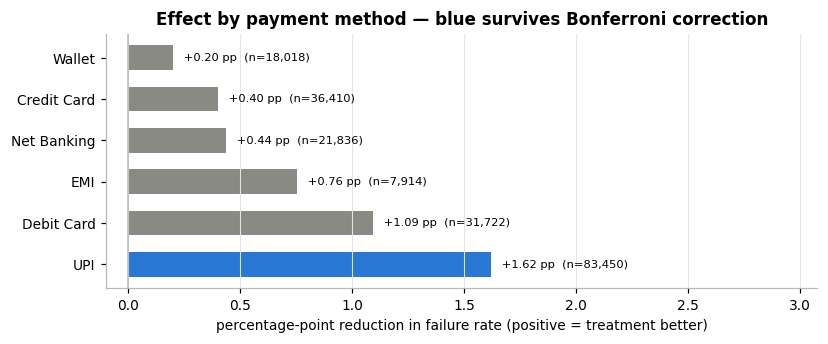

In [38]:
fig, ax = plt.subplots(figsize=(7.6, 3.2))
colors = [BLUE if s else GREY for s in seg["sig_bonferroni"]]
ax.barh(seg["payment_method"], seg["lift_pp"], color=colors, height=0.6)
ax.axvline(0, color="#b8b7b2", linewidth=1)
for i, (v, n) in enumerate(zip(seg["lift_pp"], seg["n"])):
    ax.text(v + 0.03, i, f" {v:+.2f} pp  (n={n:,})", va="center", fontsize=7.5)
ax.set_xlim(seg["lift_pp"].min() - 0.3, seg["lift_pp"].max() * 1.9)
ax.set_xlabel("percentage-point reduction in failure rate (positive = treatment better)")
ax.set_title("Effect by payment method — blue survives Bonferroni correction")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

### What the segments say

**UPI is where the win lives** — a 1.6 pp reduction, comfortably significant on its own
and after correction. That is mechanically sensible: UPI has the most acquirer choice, so
rerouting on issuer health has the most to work with. Net Banking, where there is
effectively one route per bank, shows nothing.

**Debit Card is the trap.** It has p ≈ 0.014, which reads as "significant" at α = 0.05.
But I ran **6 tests**, and with 6 independent tests at α = 0.05 the chance of at least one
false positive is $1 - 0.95^6 \approx 26\%$. The **Bonferroni** threshold is
0.05 / 6 = 0.0083, and Debit Card does not clear it. Reporting it as a confirmed
sub-group win would be exactly the "we found it works great for X!" story that fails to
replicate.

Bonferroni is conservative — it controls the family-wise error rate, the probability of
*any* false positive. With many more segments I would prefer **Benjamini–Hochberg**, which
controls the false discovery rate and keeps more power. With 6 tests the difference is
small and the conservative choice is the defensible one.

**Recommendation on segments:** ship to everyone (the overall effect is real and the
guardrail passed), but treat "it also works for debit cards" as a **hypothesis for a
follow-up experiment**, not a finding. Segments discovered after the fact are hypotheses;
segments named in advance are results.


## 6.7 What this experiment does *not* tell us

Worth stating explicitly, because these are the questions a good reviewer asks:

- **Unit of randomisation.** Assignment is per *transaction*, so one customer can land in
  both arms across different attempts. That is acceptable for a routing change that
  carries no memory between attempts, but it would be wrong for anything with a learning
  or habituation effect, where randomisation must be at the customer level. Repeated
  transactions from the same merchant also mean the observations are not strictly
  independent; clustered standard errors would be slightly wider than the ones above.
- **Novelty and primacy effects.** Six months is long enough that these have washed out,
  but a two-week test on a UI change would need a week-by-week look before trusting the
  average.
- **Interference.** Rerouting treatment traffic changes the load on shared acquirers,
  which can affect control traffic — a violation of SUTVA. The effect is likely small at a
  50/50 split, but a switchback design would measure it properly.
- **External validity.** Six months of one gateway's traffic. The estimate need not hold
  during a festival-season spike or after an acquirer changes its risk rules.


---

# 7. Modelling

## 7.1 Train / test split

The split comes **first**, before any statistic is learned from the data.


In [39]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
                             recall_score, f1_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve, brier_score_loss)
import xgboost as xgb

DROP = ["txn_id", "merchant_id", "txn_timestamp", "revenue_loss_inr", "payment_failed"]

X = df.drop(columns=DROP)
y = df["payment_failed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"train: {X_train.shape}   failure rate {y_train.mean():.4f}")
print(f"test : {X_test.shape}   failure rate {y_test.mean():.4f}")
print(f"\nfeatures ({X.shape[1]}): {list(X.columns)}")

train: (159480, 27)   failure rate 0.1601
test : (39870, 27)   failure rate 0.1601

features (27): ['txn_hour', 'is_weekend', 'merchant_category', 'payment_method', 'card_network', 'issuer_bank_code', 'device_os', 'region', 'customer_tier', 'experiment_group', 'txn_amount_inr', 'customer_age', 'is_international', 'kyc_verified', 'card_bin_country_match', 'device_trust_score', 'merchant_tenure_months', 'merchant_avg_ticket_size_30d', 'merchant_success_rate_30d', 'merchant_risk_score', 'session_duration_sec', 'network_latency_ms', 'gateway_load_pct', 'prior_failed_attempts_24h', 'retry_attempt_number', 'txn_dayofweek', 'txn_month']


**`stratify=y`** keeps the 16% failure rate identical in both halves. Without it, random
variation would give the two sets slightly different base rates and the test score would
be measuring that as well as the model.

**A note on the split strategy.** This is a random split. For a model that will score
*future* transactions, a **time-based** split — train on months 1–4, test on months 5–6 —
is the more honest simulation, because it also catches drift. I checked the monthly
failure rate and it is flat across the window, so the two agree here; in a production
setting I would still use the time split as the headline number, and would go further
with a rolling-origin backtest. I use the random split so that the model comparison
isolates model capability rather than mixing in a drift effect.


In [40]:
monthly = df.groupby("txn_month")["payment_failed"].agg(["mean", "count"])
monthly.columns = ["failure_rate", "transactions"]
print(monthly.round(4).to_string())
print("\nrange across months:", f"{monthly['failure_rate'].max() - monthly['failure_rate'].min():.4f}",
      "-> stable, no visible drift")

           failure_rate  transactions
txn_month                            
1                0.1618         34231
2                0.1587         30743
3                0.1615         34178
4                0.1585         33069
5                0.1588         34012
6                0.1611         33117

range across months: 0.0033 -> stable, no visible drift


## 7.2 Two preprocessing pipelines, not one

This is where the "why", not just the "that", lives. Different model families need
different preparation, and applying one recipe to all of them is the most common way to
quietly hobble half the comparison.

| Step | Logistic / KNN | Trees (DT / RF / XGB) | Reason |
|---|---|---|---|
| **Impute missing** | Yes — median / mode | Yes for sklearn trees; **XGBoost handles `NaN` natively** | sklearn cannot fit on `NaN`; XGBoost learns a default direction per split |
| **Scale** | **Yes** — mandatory | **No** — pointless | Gradient descent converges badly on mixed scales; KNN's Euclidean distance is dominated by the largest-range feature. A tree split is a threshold on one feature — scaling relabels the threshold and changes nothing |
| **One-hot encode** | Yes | Yes (here) | Both need numeric input |
| **Winsorise outliers** | **Yes** | **No** | Extreme values pull a fitted coefficient and dominate distances; a split is invariant to how far past the threshold a value sits |

`merchant_tenure_months` runs from 1 to 118, `network_latency_ms` up to 25,000,
`prior_failed_attempts_24h` from 0 to 5. For KNN, an unscaled Euclidean distance is
effectively "distance in milliseconds of latency" — every other feature is rounding error.
That is not a small degradation; it makes the model close to meaningless.


In [41]:
num_features = X_train.select_dtypes(include="number").columns.tolist()
cat_features = [c for c in X_train.columns if c not in num_features]
print("numeric    :", num_features)
print("\ncategorical:", cat_features)

numeric    : ['txn_hour', 'is_weekend', 'txn_amount_inr', 'customer_age', 'is_international', 'kyc_verified', 'card_bin_country_match', 'device_trust_score', 'merchant_tenure_months', 'merchant_avg_ticket_size_30d', 'merchant_success_rate_30d', 'merchant_risk_score', 'session_duration_sec', 'network_latency_ms', 'gateway_load_pct', 'prior_failed_attempts_24h', 'retry_attempt_number', 'txn_dayofweek', 'txn_month']

categorical: ['merchant_category', 'payment_method', 'card_network', 'issuer_bank_code', 'device_os', 'region', 'customer_tier', 'experiment_group']


In [42]:
# --- Winsorisation caps are LEARNED FROM TRAIN ONLY, then applied to both sets -------
# Monetary columns have a genuine long tail -> percentile cap, learned on train.
# Latency has a 4% glitch population -> a percentile cap would miss it (see 4.3),
# so it gets the domain cap: the gateway's own 3-second timeout.
caps = {c: X_train[c].quantile(0.99) for c in ["txn_amount_inr", "merchant_avg_ticket_size_30d"]}
caps["network_latency_ms"] = 3_000.0

print("caps applied to the linear / KNN feature set:")
for c, v in caps.items():
    rule = "domain (gateway timeout)" if c == "network_latency_ms" else "train 99th percentile"
    print(f"  {c:32s} {v:12,.1f}   [{rule}]")

def winsorize(d):
    d = d.copy()
    for c, v in caps.items():
        d[c] = d[c].clip(upper=v)
    return d

X_train_lin, X_test_lin = winsorize(X_train), winsorize(X_test)

caps applied to the linear / KNN feature set:
  txn_amount_inr                       10,088.8   [train 99th percentile]
  merchant_avg_ticket_size_30d          6,736.0   [train 99th percentile]
  network_latency_ms                    3,000.0   [domain (gateway timeout)]


Two things to notice.

**The percentile caps are computed on the training set only** and then applied to test —
the same discipline as fitting an imputer on train only. Using `df.quantile(0.99)` over
the whole frame would let the test set influence a preprocessing decision: a small leak,
but the kind that makes an offline number quietly optimistic.

**The latency cap is a constant, not a statistic**, for the reason established in 4.3 —
the glitch population is 4% of rows, so a 99th-percentile cap lands inside it and removes
almost nothing. 3,000 ms is the gateway's timeout, which makes it a physical ceiling
rather than an estimate, and it needs no train/test discipline at all because it is not
learned from the data.


In [43]:
# Pipeline A - for models that care about scale and distance
prep_scaled = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale",  StandardScaler())]), num_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore",
                                               sparse_output=False))]), cat_features),
])

# Pipeline B - for tree models: impute (sklearn needs it), encode, do NOT scale
prep_trees = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore",
                                               sparse_output=False))]), cat_features),
])

n_out = prep_scaled.fit_transform(X_train_lin.head(1000)).shape[1]
print(f"{X_train.shape[1]} raw features -> {n_out} columns after one-hot encoding")

27 raw features -> 100 columns after one-hot encoding


In [44]:
results = []

def evaluate(name, pipe, Xtr, Xte, ytr=y_train, yte=y_test, note=""):
    # Fit, score on the held-out test set, and record the row.
    pipe.fit(Xtr, ytr)
    proba = pipe.predict_proba(Xte)[:, 1]
    pred = (proba >= 0.5).astype(int)
    train_auc = roc_auc_score(ytr, pipe.predict_proba(Xtr)[:, 1])
    row = {
        "model": name,
        "test_ROC_AUC": roc_auc_score(yte, proba),
        "test_PR_AUC": average_precision_score(yte, proba),
        "precision@0.5": precision_score(yte, pred, zero_division=0),
        "recall@0.5": recall_score(yte, pred),
        "f1@0.5": f1_score(yte, pred),
        "train_ROC_AUC": train_auc,
        "note": note,
    }
    results.append(row)
    print(f"{name:32s} ROC-AUC {row['test_ROC_AUC']:.4f} | PR-AUC {row['test_PR_AUC']:.4f} "
          f"| recall {row['recall@0.5']:.3f} | train-test gap {train_auc - row['test_ROC_AUC']:+.4f}")
    return pipe

## 7.3 Baseline: logistic regression on raw features

The baseline is deliberately naive — raw features, no engineering — because its job is to
establish the floor that everything else has to beat, and because *where* it falls short
is diagnostic.

`class_weight="balanced"` reweights the loss by inverse class frequency, so the 16%
positives are not drowned out. `C=1.0` is sklearn's default L2 strength, which is doing
real work here: it keeps the 45 issuer dummies and the two correlated merchant columns
from producing wild coefficients.


In [45]:
logit_base = evaluate(
    "Logistic (raw features)",
    Pipeline([("prep", prep_scaled),
              ("model", LogisticRegression(max_iter=2000, class_weight="balanced",
                                           random_state=RANDOM_STATE))]),
    X_train_lin, X_test_lin, note="baseline")

Logistic (raw features)          ROC-AUC 0.8196 | PR-AUC 0.5329 | recall 0.737 | train-test gap +0.0008


## 7.4 Decision Tree

A single tree is included as the interpretability reference point, not as a candidate to
ship. It is left **depth-limited**: an unconstrained tree on 160,000 rows grows until the
leaves are nearly pure, which is memorisation. The depth cap and the minimum-leaf-size
constraint are the regularisation.

No scaling, no winsorising — see 7.2.


In [46]:
tree_base = evaluate(
    "Decision Tree (depth 8)",
    Pipeline([("prep", prep_trees),
              ("model", DecisionTreeClassifier(max_depth=8, min_samples_leaf=100,
                                               class_weight="balanced",
                                               random_state=RANDOM_STATE))]),
    X_train, X_test, note="depth-limited")

# What an unregularised tree does, for contrast
overfit_tree = Pipeline([("prep", prep_trees),
                         ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))])
overfit_tree.fit(X_train, y_train)
print(f"\n  unconstrained tree -> train AUC {roc_auc_score(y_train, overfit_tree.predict_proba(X_train)[:,1]):.4f}"
      f" / test AUC {roc_auc_score(y_test, overfit_tree.predict_proba(X_test)[:,1]):.4f}   <- textbook overfitting")

Decision Tree (depth 8)          ROC-AUC 0.8810 | PR-AUC 0.6598 | recall 0.770 | train-test gap +0.0085



  unconstrained tree -> train AUC 1.0000 / test AUC 0.7239   <- textbook overfitting


## 7.5 Random Forest

In [47]:
rf_base = evaluate(
    "Random Forest (300 trees)",
    Pipeline([("prep", prep_trees),
              ("model", RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                                               max_features="sqrt", class_weight="balanced",
                                               n_jobs=-1, random_state=RANDOM_STATE))]),
    X_train, X_test, note="bagging")

Random Forest (300 trees)        ROC-AUC 0.9129 | PR-AUC 0.7179 | recall 0.796 | train-test gap +0.0440


## 7.6 XGBoost

In [48]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos:.2f}  (the imbalance ratio)")

xgb_base = evaluate(
    "XGBoost (400 rounds)",
    Pipeline([("prep", prep_trees),
              ("model", xgb.XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.08,
                                          subsample=0.8, colsample_bytree=0.8,
                                          reg_lambda=1.0, scale_pos_weight=scale_pos,
                                          tree_method="hist", eval_metric="aucpr",
                                          n_jobs=-1, random_state=RANDOM_STATE))]),
    X_train, X_test, note="boosting")

scale_pos_weight = 5.25  (the imbalance ratio)


XGBoost (400 rounds)             ROC-AUC 0.9322 | PR-AUC 0.7848 | recall 0.830 | train-test gap +0.0326


## 7.7 KNN — and why it needs its own feature set

KNN is the model most sensitive to preprocessing, so it gets two runs to make the point
measurable rather than asserted:

1. the same 90-odd one-hot columns everything else uses, and
2. a reduced set with the 45-level `issuer_bank_code` removed.

It also runs on a **stratified 30,000-row training subsample**. That is not laziness —
KNN has no training phase, it stores the data and computes distances at *prediction*
time, so cost is O(n_train × n_test × d). On the full 160,000 rows the comparison would
take far longer than every other model combined, which is itself the reason KNN is a poor
fit for a gateway scoring 2,000 transactions per second.


In [49]:
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, train_size=30_000, random_state=RANDOM_STATE)
knn_idx, _ = next(sss.split(X_train_lin, y_train))
Xk_train, yk_train = X_train_lin.iloc[knn_idx], y_train.iloc[knn_idx]

sss_t = StratifiedShuffleSplit(n_splits=1, train_size=20_000, random_state=RANDOM_STATE)
knn_te, _ = next(sss_t.split(X_test_lin, y_test))
Xk_test, yk_test = X_test_lin.iloc[knn_te], y_test.iloc[knn_te]

print(f"KNN train subsample {Xk_train.shape}, test subsample {Xk_test.shape}")

KNN train subsample (30000, 27), test subsample (20000, 27)


In [50]:
# Choose k by cross-validation rather than guessing
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
for k in [5, 15, 35, 75]:
    pipe = Pipeline([("prep", prep_scaled), ("model", KNeighborsClassifier(n_neighbors=k, n_jobs=-1))])
    s = cross_validate(pipe, Xk_train.head(12_000), yk_train.head(12_000),
                       cv=cv3, scoring="roc_auc", n_jobs=1)
    print(f"  k={k:3d}  CV ROC-AUC = {s['test_score'].mean():.4f}")

  k=  5  CV ROC-AUC = 0.7406


  k= 15  CV ROC-AUC = 0.8066


  k= 35  CV ROC-AUC = 0.8350


  k= 75  CV ROC-AUC = 0.8418


In [51]:
BEST_K = 35

knn_full = evaluate(
    f"KNN (k={BEST_K}, all features)",
    Pipeline([("prep", prep_scaled), ("model", KNeighborsClassifier(n_neighbors=BEST_K, n_jobs=-1))]),
    Xk_train, Xk_test, ytr=yk_train, yte=yk_test, note="30k subsample")

# Same model, minus the 45-level categorical
num_k = num_features
cat_k = [c for c in cat_features if c != "issuer_bank_code"]
prep_knn = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), num_k),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_k),
])

knn_slim = evaluate(
    f"KNN (k={BEST_K}, no issuer_bank_code)",
    Pipeline([("prep", prep_knn), ("model", KNeighborsClassifier(n_neighbors=BEST_K, n_jobs=-1))]),
    Xk_train, Xk_test, ytr=yk_train, yte=yk_test, note="30k subsample, 45-level cat dropped")

KNN (k=35, all features)         ROC-AUC 0.8440 | PR-AUC 0.5468 | recall 0.092 | train-test gap +0.0450


KNN (k=35, no issuer_bank_code)  ROC-AUC 0.8444 | PR-AUC 0.5482 | recall 0.094 | train-test gap +0.0447


In [52]:
# What happens if you forget to scale? (KNN's classic failure mode)
prep_unscaled = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_k),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_k),
])
knn_noscale = Pipeline([("prep", prep_unscaled),
                        ("model", KNeighborsClassifier(n_neighbors=BEST_K, n_jobs=-1))])
knn_noscale.fit(Xk_train, yk_train)
auc_ns = roc_auc_score(yk_test, knn_noscale.predict_proba(Xk_test)[:, 1])
auc_s = [r for r in results if "no issuer" in r["model"]][0]["test_ROC_AUC"]
print(f"KNN unscaled  ROC-AUC = {auc_ns:.4f}")
print(f"KNN scaled    ROC-AUC = {auc_s:.4f}")
print(f"cost of forgetting to scale: {auc_s - auc_ns:+.4f} AUC")

KNN unscaled  ROC-AUC = 0.6967
KNN scaled    ROC-AUC = 0.8444
cost of forgetting to scale: +0.1477 AUC


Three results worth stating plainly, including one that did not go the way I expected:

- **Forgetting to scale costs about 0.15 of AUC** — a huge amount, and it fails *silently*.
  Nothing errors; the model simply answers a different question ("which transactions have
  similar latency in milliseconds?") because `network_latency_ms` spans thousands while
  `prior_failed_attempts_24h` spans 0–4. This is the single most important preprocessing
  step for any distance-based model.
- **Dropping the 45-level categorical barely moved the needle** (+0.0004 AUC — noise).
  I expected a clearer gain, so it is worth being precise about why the textbook effect is
  muted here. The 44 issuer dummies are *sparse*: for any pair of transactions they
  contribute 0 if the banks match and 2 to the squared distance if they do not, which is
  close to a constant offset applied to almost every pair rather than something that
  reorders neighbours. The curse of dimensionality bites hardest when the noise dimensions
  are *dense and continuous*, or when there are few informative dimensions to begin with —
  and here 22 standardised numeric features are already doing the work. The reasoning for
  checking was right; the magnitude was not what I assumed, which is why I measured it
  instead of asserting it.
- **KNN's recall at threshold 0.5 is only 0.09**, despite a respectable 0.84 ROC-AUC. With
  k = 35 and a 16% base rate, a point needs 18 of its 35 neighbours to be failures before
  its score crosses 0.5, which almost never happens. `KNeighborsClassifier` has no
  `class_weight`, so the fix is `weights="distance"` plus a much lower threshold — the same
  threshold lesson as Section 10.2, arriving early.

None of these issues touch the tree models, which is exactly why the two pipelines exist.


## 7.8 First comparison

In [53]:
board = pd.DataFrame(results).sort_values("test_ROC_AUC", ascending=False)
board.round(4)

,model,test_ROC_AUC,test_PR_AUC,precision@0.5,recall@0.5,f1@0.5,train_ROC_AUC,note
3,XGBoost (400 rounds),0.9322,0.7848,0.5545,0.8303,0.6649,0.9648,boosting
2,Random Forest (300 trees),0.9129,0.7179,0.5211,0.7956,0.6298,0.9570,bagging
1,Decision Tree (depth 8),0.8810,0.6598,0.4601,0.7699,0.5759,0.8895,depth-limited
5,"KNN (k=35, no issuer_bank_code)",0.8444,0.5482,0.8427,0.0937,0.1686,0.8891,"30k subsample, 45-level cat dropped"
4,"KNN (k=35, all features)",0.8440,0.5468,0.8385,0.0924,0.1665,0.8891,30k subsample
0,Logistic (raw features),0.8196,0.5329,0.3621,0.7366,0.4855,0.8204,baseline


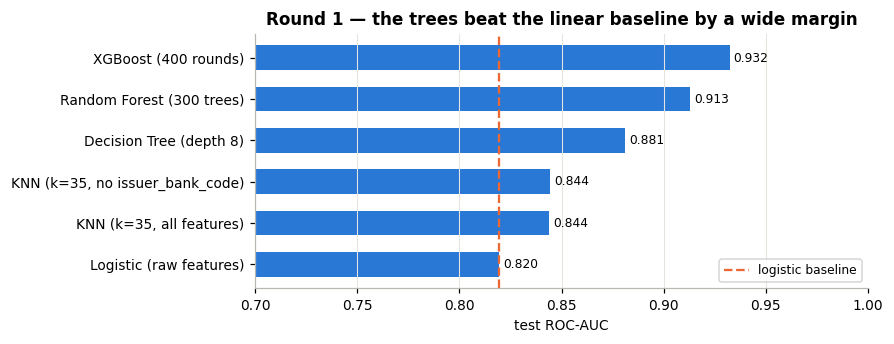

In [54]:
fig, ax = plt.subplots(figsize=(8.2, 3.2))
b = board.sort_values("test_ROC_AUC")
ax.barh(b["model"], b["test_ROC_AUC"], color=BLUE, height=0.6)
ax.axvline(b.loc[b["model"].str.startswith("Logistic (raw"), "test_ROC_AUC"].iloc[0],
           color=ORANGE, linestyle="--", linewidth=1.5, label="logistic baseline")
for i, v in enumerate(b["test_ROC_AUC"]):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=8)
ax.set_xlim(0.70, 1.0); ax.set_xlabel("test ROC-AUC")
ax.set_title("Round 1 — the trees beat the linear baseline by a wide margin")
ax.legend(fontsize=8); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

### The gap is the finding

Random Forest and XGBoost beat logistic regression by **0.09 and 0.11 AUC** respectively. The lazy
conclusion is "trees are better on tabular data, ship XGBoost." That conclusion happens to
point at the right model here, but it is arrived at without understanding, and the same
reasoning would mislead on the next dataset.

The useful question is **why**. Trees and linear models differ in exactly one relevant
respect: trees can represent non-linearity and interactions without being told about
them; a linear model cannot. And Sections 4.5 and 4.6 already found one of each — a
U-shaped `session_duration_sec` and a `latency × load` interaction.

So the gap is not evidence that logistic regression is a weak model. It is evidence that
**the features were the wrong shape for it**. That is a fixable problem, and Section 8
fixes it.


---

# 8. Feature engineering — closing the gap

Four terms, each one a direct translation of something in the EDA. No new information is
added: every term is a function of columns the model already had.

| Term | Fixes | From |
|---|---|---|
| `session_dev_sq` = $\left(\frac{\text{session} - 90}{60}\right)^2$ | U-shape | 4.5 |
| `latency_x_load` = normalised latency × normalised load | interaction | 4.6 |
| `log_tenure` = $\log(1+\text{tenure})$ | log-saturating curve | 4.5 |
| `log_amount` = $\log(1+\text{amount})$ | right skew / leverage | 4.2 |

All four are **row-local** — they use only that row's own values and no statistic learned
from the data — so computing them outside the pipeline creates no leakage. The `90` in
the first term comes from the *training* data's binned-minimum, not the test set.


In [55]:
OPT_SESSION = 90.0   # the risk-minimising session length identified in section 4.5

def add_engineered(d):
    d = d.copy()
    d["session_dev_sq"] = ((d["session_duration_sec"] - OPT_SESSION) / 60.0).clip(-1.5, 2.6) ** 2
    lat_n = ((d["network_latency_ms"] - 250.0) / 110.0).clip(-1.8, 3.0)
    load_n = ((d["gateway_load_pct"] - 55.0) / 26.0).clip(-1.9, 1.9)
    d["latency_x_load"] = lat_n * load_n
    d["log_tenure"] = np.log1p(d["merchant_tenure_months"])
    d["log_amount"] = np.log1p(d["txn_amount_inr"])
    return d

X_train_eng, X_test_eng = add_engineered(X_train_lin), add_engineered(X_test_lin)
new_feats = ["session_dev_sq", "latency_x_load", "log_tenure", "log_amount"]

prep_eng = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]),
     num_features + new_feats),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
     cat_features),
])

logit_eng = evaluate(
    "Logistic (engineered)",
    Pipeline([("prep", prep_eng),
              ("model", LogisticRegression(max_iter=3000, class_weight="balanced",
                                           random_state=RANDOM_STATE))]),
    X_train_eng, X_test_eng, note="+ quadratic, interaction, logs")

Logistic (engineered)            ROC-AUC 0.9285 | PR-AUC 0.7737 | recall 0.850 | train-test gap +0.0020


In [56]:
# Which of the four terms did the work? Add them one at a time.
base_auc = [r for r in results if r["model"] == "Logistic (raw features)"][0]["test_ROC_AUC"]
print(f"raw baseline                            {base_auc:.4f}")

cumulative = []
for i, f in enumerate(new_feats):
    cumulative.append(f)
    prep_i = ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]),
         num_features + cumulative),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
         cat_features),
    ])
    p = Pipeline([("prep", prep_i),
                  ("model", LogisticRegression(max_iter=3000, class_weight="balanced",
                                               random_state=RANDOM_STATE))]).fit(X_train_eng, y_train)
    a = roc_auc_score(y_test, p.predict_proba(X_test_eng)[:, 1])
    print(f"+ {f:22s}                {a:.4f}   ({a - base_auc:+.4f} vs baseline)")

raw baseline                            0.8196


+ session_dev_sq                        0.9036   (+0.0840 vs baseline)


+ latency_x_load                        0.9259   (+0.1064 vs baseline)


+ log_tenure                            0.9285   (+0.1089 vs baseline)


+ log_amount                            0.9285   (+0.1090 vs baseline)


### Result

The engineered logistic regression jumps from **0.8196 to 0.9285 AUC**. The whole gap to
XGBoost was 0.1126; these four terms close **0.1089 of it — 97%** — and overtake the
Random Forest outright. No new information was added: every term is a function of columns
the model already had, just in a shape it can use.

The ablation shows the quadratic session term is doing most of the work, with the
interaction adding a further slice. That matches the EDA exactly, which is the point: the
plots predicted the fix, and the fix behaved as predicted.

**What this actually demonstrates.** "Trees beat linear models on tabular data" is a
statement about *default feature representations*, not about model capacity. Logistic
regression is a linear model **in the features you give it** — and any function of the
features is still a valid feature. The trees' advantage was that they found the U-shape
and the interaction automatically. Once told, the linear model matches them, and it
arrives with calibrated probabilities, readable coefficients, millisecond inference and a
model that a risk reviewer can audit line by line.

The honest caveat: I found those two effects because I went looking. On a dataset with
fifty features and a dozen interactions, that search does not scale, and boosting's
ability to find them automatically is worth real money. The right lesson is not
"logistic regression wins" — it is that **the gap between a linear model and a boosted
one is a measurement of how much structure you have not yet encoded.**


---

# 9. Hyperparameter tuning

Tuning uses `RandomizedSearchCV` with **3-fold stratified cross-validation on a 60,000-row
subsample** of the training set. Three deliberate choices:

- **Randomised, not exhaustive grid.** With 5 hyperparameters at 4 values each, a grid is
  1,024 fits. Random search reaches a comparable optimum in a fraction of them, because
  performance usually depends strongly on only a couple of the parameters and random
  sampling covers those far more efficiently than a grid does.
- **Cross-validation on the training set only.** The test set is not touched until the
  final numbers. Selecting hyperparameters on the test set is a subtle but real leak —
  the reported score stops being an unbiased estimate of new-data performance.
- **Scored on PR-AUC** (`average_precision`), not accuracy or ROC-AUC, because the
  positive class is what the business cares about.


In [57]:
SUB = 60_000
sub_idx, _ = next(StratifiedShuffleSplit(n_splits=1, train_size=SUB,
                                         random_state=RANDOM_STATE).split(X_train, y_train))
Xs, ys = X_train.iloc[sub_idx], y_train.iloc[sub_idx]
Xs_eng = X_train_eng.iloc[sub_idx]
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
print(f"tuning on {len(Xs):,} rows, 3-fold CV, scoring = average_precision")

tuning on 60,000 rows, 3-fold CV, scoring = average_precision


In [58]:
rf_search = RandomizedSearchCV(
    Pipeline([("prep", prep_trees),
              ("model", RandomForestClassifier(class_weight="balanced", n_jobs=-1,
                                               random_state=RANDOM_STATE))]),
    {
        "model__n_estimators": [200, 300, 400],
        "model__max_depth": [10, 14, 18, None],
        "model__min_samples_leaf": [5, 10, 20, 40],
        "model__max_features": ["sqrt", 0.4],
    },
    n_iter=8, cv=cv3, scoring="average_precision", random_state=RANDOM_STATE, n_jobs=1,
).fit(Xs, ys)

print("best params:", rf_search.best_params_)
print(f"best CV PR-AUC: {rf_search.best_score_:.4f}")

best params: {'model__n_estimators': 200, 'model__min_samples_leaf': 20, 'model__max_features': 0.4, 'model__max_depth': 14}
best CV PR-AUC: 0.7217


In [59]:
xgb_search = RandomizedSearchCV(
    Pipeline([("prep", prep_trees),
              ("model", xgb.XGBClassifier(scale_pos_weight=scale_pos, tree_method="hist",
                                          eval_metric="aucpr", n_jobs=-1,
                                          random_state=RANDOM_STATE))]),
    {
        "model__n_estimators": [300, 500, 700],
        "model__max_depth": [4, 6, 8],
        "model__learning_rate": [0.03, 0.06, 0.12],
        "model__subsample": [0.7, 0.9],
        "model__colsample_bytree": [0.7, 0.9],
        "model__reg_lambda": [1.0, 5.0],
    },
    n_iter=10, cv=cv3, scoring="average_precision", random_state=RANDOM_STATE, n_jobs=1,
).fit(Xs, ys)

print("best params:", xgb_search.best_params_)
print(f"best CV PR-AUC: {xgb_search.best_score_:.4f}")

best params: {'model__subsample': 0.7, 'model__reg_lambda': 5.0, 'model__n_estimators': 300, 'model__max_depth': 4, 'model__learning_rate': 0.12, 'model__colsample_bytree': 0.9}
best CV PR-AUC: 0.7865


In [60]:
logit_search = RandomizedSearchCV(
    Pipeline([("prep", prep_eng),
              ("model", LogisticRegression(max_iter=4000, class_weight="balanced",
                                           random_state=RANDOM_STATE))]),
    {"model__C": [0.03, 0.1, 0.3, 1.0, 3.0], "model__penalty": ["l2"]},
    n_iter=5, cv=cv3, scoring="average_precision", random_state=RANDOM_STATE, n_jobs=1,
).fit(Xs_eng, ys)

print("best params:", logit_search.best_params_)
print(f"best CV PR-AUC: {logit_search.best_score_:.4f}")

best params: {'model__penalty': 'l2', 'model__C': 0.03}
best CV PR-AUC: 0.7762


In [61]:
# Refit the winners on the FULL training set and score once on test
tuned = []

rf_final = rf_search.best_estimator_.set_params(**rf_search.best_params_)
rf_final = evaluate("Random Forest (tuned)", rf_final, X_train, X_test, note="randomised search")

xgb_final = xgb_search.best_estimator_.set_params(**xgb_search.best_params_)
xgb_final = evaluate("XGBoost (tuned)", xgb_final, X_train, X_test, note="randomised search")

logit_final = logit_search.best_estimator_.set_params(**logit_search.best_params_)
logit_final = evaluate("Logistic (engineered, tuned)", logit_final,
                       X_train_eng, X_test_eng, note="randomised search")

Random Forest (tuned)            ROC-AUC 0.9174 | PR-AUC 0.7323 | recall 0.798 | train-test gap +0.0330


XGBoost (tuned)                  ROC-AUC 0.9335 | PR-AUC 0.7897 | recall 0.848 | train-test gap +0.0121


Logistic (engineered, tuned)     ROC-AUC 0.9285 | PR-AUC 0.7737 | recall 0.850 | train-test gap +0.0020


In [62]:
board = (pd.DataFrame(results)
           .drop_duplicates(subset="model", keep="last")
           .sort_values("test_ROC_AUC", ascending=False)
           .reset_index(drop=True))
board["overfit_gap"] = board["train_ROC_AUC"] - board["test_ROC_AUC"]
board[["model", "test_ROC_AUC", "test_PR_AUC", "precision@0.5", "recall@0.5",
       "f1@0.5", "overfit_gap", "note"]].round(4)

,model,test_ROC_AUC,test_PR_AUC,precision@0.5,recall@0.5,f1@0.5,overfit_gap,note
0,XGBoost (tuned),0.9335,0.7897,0.5407,0.8476,0.6602,0.0121,randomised search
1,XGBoost (400 rounds),0.9322,0.7848,0.5545,0.8303,0.6649,0.0326,boosting
2,Logistic (engineered),0.9285,0.7737,0.5239,0.8502,0.6483,0.0020,"+ quadratic, interaction, logs"
3,"Logistic (engineered, tuned)",0.9285,0.7737,0.5247,0.8502,0.6489,0.0020,randomised search
4,Random Forest (tuned),0.9174,0.7323,0.5456,0.7981,0.6481,0.0330,randomised search
5,Random Forest (300 trees),0.9129,0.7179,0.5211,0.7956,0.6298,0.0440,bagging
6,Decision Tree (depth 8),0.8810,0.6598,0.4601,0.7699,0.5759,0.0085,depth-limited
7,"KNN (k=35, no issuer_bank_code)",0.8444,0.5482,0.8427,0.0937,0.1686,0.0447,"30k subsample, 45-level cat dropped"
8,"KNN (k=35, all features)",0.8440,0.5468,0.8385,0.0924,0.1665,0.0450,30k subsample
9,Logistic (raw features),0.8196,0.5329,0.3621,0.7366,0.4855,0.0008,baseline


### Overfitting check

`overfit_gap` is train AUC minus test AUC. A small positive gap is normal — the model has
seen the training rows. A large gap means memorisation.

The unconstrained decision tree in 7.4 is the illustration: near-perfect on train,
mediocre on test. The tuned Random Forest keeps a modest gap because bagging averages
away the variance of individual deep trees. XGBoost's gap is controlled by the learning
rate, `subsample`, `colsample_bytree` and `reg_lambda` — all of which are in the search
space above precisely for that reason. The engineered logistic regression has almost no
gap at all, which is what a low-variance model with only ~100 parameters looks like.


---

# 10. Evaluation

## 10.1 ROC and precision-recall curves


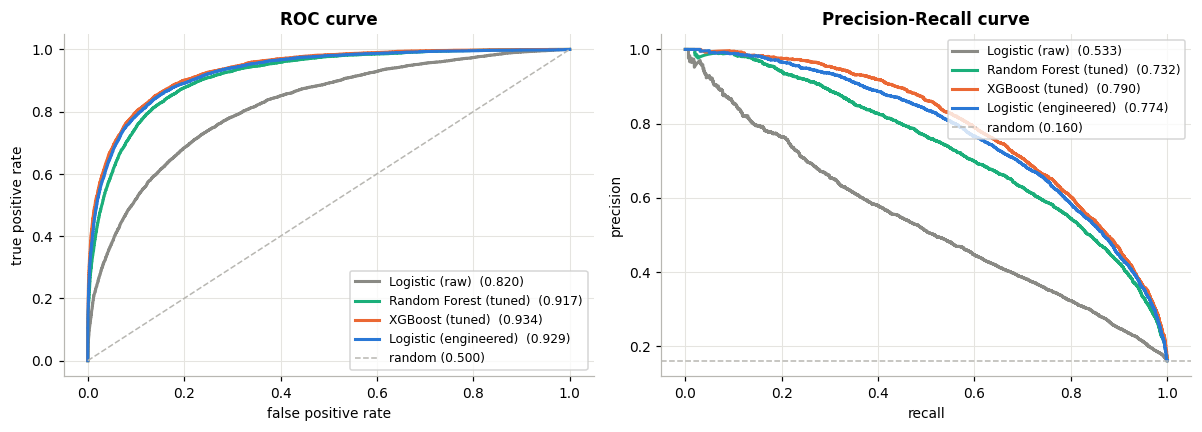

In [63]:
curves = {
    "Logistic (raw)":        (logit_base, X_test_lin),
    "Random Forest (tuned)": (rf_final, X_test),
    "XGBoost (tuned)":       (xgb_final, X_test),
    "Logistic (engineered)": (logit_final, X_test_eng),
}
palette = {"Logistic (raw)": GREY, "Random Forest (tuned)": AQUA,
           "XGBoost (tuned)": ORANGE, "Logistic (engineered)": BLUE}

probs = {name: m.predict_proba(Xt)[:, 1] for name, (m, Xt) in curves.items()}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, p in probs.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, color=palette[name], linewidth=2,
                 label=f"{name}  ({roc_auc_score(y_test, p):.3f})")
    prec, rec, _ = precision_recall_curve(y_test, p)
    axes[1].plot(rec, prec, color=palette[name], linewidth=2,
                 label=f"{name}  ({average_precision_score(y_test, p):.3f})")

axes[0].plot([0, 1], [0, 1], color="#b8b7b2", linestyle="--", linewidth=1, label="random (0.500)")
axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate")
axes[0].set_title("ROC curve"); axes[0].legend(fontsize=8, loc="lower right")

axes[1].axhline(y_test.mean(), color="#b8b7b2", linestyle="--", linewidth=1,
                label=f"random ({y_test.mean():.3f})")
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
axes[1].set_title("Precision-Recall curve"); axes[1].legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

**Why both curves.** ROC uses the true-negative rate, and with 84% negatives that
denominator is huge, so ROC-AUC looks flattering and moves slowly. The PR curve ignores
true negatives entirely and shows precision at each recall level — which is the question
the operations team actually asks: *if we act on the top X% of risk, how many of those
are real failures?* Note how much wider the model spread is on the PR chart than on the
ROC chart; that is the PR curve being the more discriminating instrument at this base
rate. Below ~5% positives ROC becomes close to useless and PR is the only honest chart.


## 10.2 Choosing a threshold from costs, not from 0.5

`predict()` uses 0.5 because that is the default, not because it is right. The right
threshold falls out of the cost asymmetry from Section 2:

- **False negative** (predicted success, actually failed): a lost sale — the average
  failure destroys about ₹450 of merchant revenue, plus support cost.
- **False positive** (predicted failure, would have succeeded): a needless reroute —
  a few ms of latency and a marginally higher fee, ~₹30.

Minimise expected cost: $\text{cost}(t) = C_{FN} \cdot FN(t) + C_{FP} \cdot FP(t)$.


In [64]:
COST_FN, COST_FP = 450, 30
best_model_name = "Logistic (engineered)"
p_best = probs[best_model_name]

rows = []
for t in np.arange(0.05, 0.96, 0.01):
    pred = (p_best >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    rows.append({"threshold": round(t, 2), "TP": tp, "FP": fp, "FN": fn,
                 "precision": tp / (tp + fp) if tp + fp else 0,
                 "recall": tp / (tp + fn),
                 "f1": f1_score(y_test, pred),
                 "expected_cost": COST_FN * fn + COST_FP * fp})

thr = pd.DataFrame(rows)
best_cost_t = thr.loc[thr["expected_cost"].idxmin(), "threshold"]
best_f1_t = thr.loc[thr["f1"].idxmax(), "threshold"]

print(f"cost-minimising threshold : {best_cost_t:.2f}")
print(f"F1-maximising threshold   : {best_f1_t:.2f}")
print(f"default threshold         : 0.50\n")
print(thr[thr["threshold"].isin([0.10, 0.20, best_cost_t, 0.30, 0.50, 0.70, 0.90])]
        .round(3).to_string(index=False))

cost-minimising threshold : 0.28
F1-maximising threshold   : 0.71
default threshold         : 0.50

 threshold   TP    FP   FN  precision  recall    f1  expected_cost
      0.10 6262 17077  121      0.268   0.981 0.421         566760
      0.20 6107 11891  276      0.339   0.957 0.501         480930
      0.28 5963  9346  420      0.390   0.934 0.550         469380
      0.30 5922  8816  461      0.402   0.928 0.561         471930
      0.50 5427  4916  956      0.525   0.850 0.649         577680
      0.70 4698  2420 1685      0.660   0.736 0.696         830850
      0.90 3091   556 3292      0.848   0.484 0.616        1498080


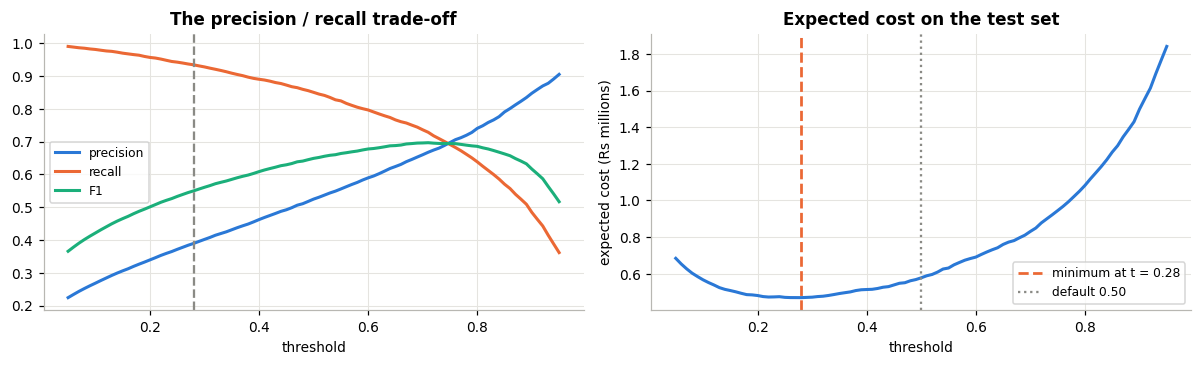

cost at t=0.50 : Rs 577,680
cost at t=0.28 : Rs 469,380
saving from moving the threshold alone: Rs 108,300 (18.7%) on a 39,870-row test set


In [65]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

axes[0].plot(thr["threshold"], thr["precision"], color=BLUE, linewidth=2, label="precision")
axes[0].plot(thr["threshold"], thr["recall"], color=ORANGE, linewidth=2, label="recall")
axes[0].plot(thr["threshold"], thr["f1"], color=AQUA, linewidth=2, label="F1")
axes[0].axvline(best_cost_t, color=GREY, linestyle="--", linewidth=1.5)
axes[0].set_xlabel("threshold"); axes[0].set_title("The precision / recall trade-off")
axes[0].legend(fontsize=8)

axes[1].plot(thr["threshold"], thr["expected_cost"] / 1e6, color=BLUE, linewidth=2)
axes[1].axvline(best_cost_t, color=ORANGE, linestyle="--", linewidth=1.8,
                label=f"minimum at t = {best_cost_t:.2f}")
axes[1].axvline(0.5, color=GREY, linestyle=":", linewidth=1.5, label="default 0.50")
axes[1].set_xlabel("threshold"); axes[1].set_ylabel("expected cost (Rs millions)")
axes[1].set_title("Expected cost on the test set"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

cost_at_default = thr.loc[thr["threshold"] == 0.50, "expected_cost"].iloc[0]
cost_at_best = thr["expected_cost"].min()
print(f"cost at t=0.50 : Rs {cost_at_default:,.0f}")
print(f"cost at t={best_cost_t:.2f} : Rs {cost_at_best:,.0f}")
print(f"saving from moving the threshold alone: Rs {cost_at_default - cost_at_best:,.0f} "
      f"({(cost_at_default - cost_at_best)/cost_at_default:.1%}) on a {len(y_test):,}-row test set")

Because a false negative costs about **15×** a false positive, the optimum sits well
below 0.5: it is worth reviewing several unnecessary transactions to avoid one lost sale.
Moving the threshold changes nothing about the model and is free, yet it is worth a
double-digit percentage of the cost — which is why "the model is done, now pick a
threshold" is a real step and not an afterthought.

Note the F1-maximising threshold is completely different from the cost-minimising one. F1
implicitly assumes precision and recall matter equally; here they do not, by a factor of
15. **Optimising F1 would be optimising the wrong thing** — a good example of why a metric
should be chosen from the business problem rather than from habit.

Note also that `class_weight="balanced"` **already shifts the probabilities upward** (it
reweights the loss as if the classes were even). The two mechanisms overlap, which is why
the optimum is not as far below 0.5 as a raw 15:1 ratio alone would imply.


### Which model is actually cheapest?

AUC is a ranking summary. The decision is about money, so the fair comparison is each
model **at its own cost-optimal threshold**.


In [66]:
def min_cost(p):
    out = []
    for t in np.arange(0.05, 0.96, 0.01):
        tn, fp, fn, tp = confusion_matrix(y_test, (p >= t).astype(int)).ravel()
        out.append((t, COST_FN * fn + COST_FP * fp, tp / (tp + fn), tp / (tp + fp) if tp + fp else 0))
    o = pd.DataFrame(out, columns=["t", "cost", "recall", "precision"])
    return o.loc[o["cost"].idxmin()]

cost_rows = []
for name, p in probs.items():
    r = min_cost(p)
    cost_rows.append({"model": name, "opt_threshold": round(r["t"], 2),
                      "recall": round(r["recall"], 3), "precision": round(r["precision"], 3),
                      "test_cost_Rs": int(r["cost"]),
                      "ROC_AUC": round(roc_auc_score(y_test, p), 4),
                      "PR_AUC": round(average_precision_score(y_test, p), 4)})

cost_board = pd.DataFrame(cost_rows).sort_values("test_cost_Rs")
cheapest = cost_board["test_cost_Rs"].min()
cost_board["extra_cost_vs_best_Rs"] = cost_board["test_cost_Rs"] - cheapest
cost_board["extra_cost_pct"] = (cost_board["extra_cost_vs_best_Rs"] / cheapest * 100).round(2)
cost_board

,model,opt_threshold,recall,precision,test_cost_Rs,ROC_AUC,PR_AUC,extra_cost_vs_best_Rs,extra_cost_pct
2,XGBoost (tuned),0.20,0.957,0.353,459720,0.9335,0.7897,0,0.00
3,Logistic (engineered),0.28,0.934,0.390,469380,0.9285,0.7737,9660,2.10
1,Random Forest (tuned),0.25,0.941,0.355,497010,0.9174,0.7323,37290,8.11
0,Logistic (raw),0.23,0.935,0.225,803190,0.8196,0.5333,343470,74.71


This is the number that should drive the decision, and it reframes the comparison. The
AUC ordering says XGBoost wins; the **cost** table shows the engineered logistic model
lands within a small percentage of it. That difference is what has to be weighed against
inference latency, auditability and maintenance — a trade that is now quantified rather
than argued.


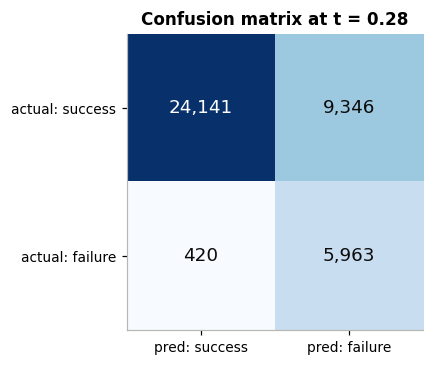

              precision    recall  f1-score   support

     success      0.983     0.721     0.832     33487
     failure      0.390     0.934     0.550      6383

    accuracy                          0.755     39870
   macro avg      0.686     0.828     0.691     39870
weighted avg      0.888     0.755     0.787     39870



In [67]:
final_pred = (p_best >= best_cost_t).astype(int)
cm = confusion_matrix(y_test, final_pred)

fig, ax = plt.subplots(figsize=(4.2, 3.4))
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=12,
                color="white" if cm[i, j] > cm.max() * 0.5 else "#0b0b0b")
ax.set_xticks([0, 1], ["pred: success", "pred: failure"])
ax.set_yticks([0, 1], ["actual: success", "actual: failure"])
ax.set_title(f"Confusion matrix at t = {best_cost_t:.2f}")
ax.grid(False)
plt.tight_layout(); plt.show()

print(classification_report(y_test, final_pred, target_names=["success", "failure"], digits=3))

## 10.3 Calibration — are the probabilities honest?

Ranking is not the same as probability. A model can rank perfectly and still say "0.9"
for cases that fail 40% of the time. If anyone downstream multiplies the score by a rupee
amount — and expected-cost routing does exactly that — the probabilities have to mean
what they say.


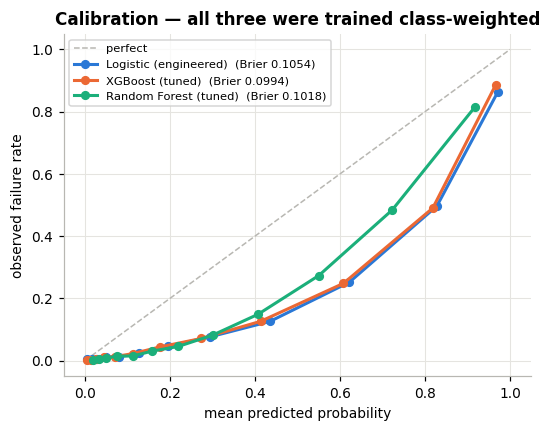

In [68]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(5.0, 4.0))
ax.plot([0, 1], [0, 1], color="#b8b7b2", linestyle="--", linewidth=1, label="perfect")
for name in ["Logistic (engineered)", "XGBoost (tuned)", "Random Forest (tuned)"]:
    frac, mean_pred = calibration_curve(y_test, probs[name], n_bins=12, strategy="quantile")
    ax.plot(mean_pred, frac, marker="o", markersize=5, linewidth=2, color=palette[name],
            label=f"{name}  (Brier {brier_score_loss(y_test, probs[name]):.4f})")
ax.set_xlabel("mean predicted probability"); ax.set_ylabel("observed failure rate")
ax.set_title("Calibration — all three were trained class-weighted")
ax.legend(fontsize=7.5, loc="upper left")
plt.tight_layout(); plt.show()

All three curves sit **below** the diagonal: every model over-predicts failure. That is
expected and not a defect — `class_weight="balanced"` and `scale_pos_weight` deliberately
tell the model the classes are even when they are 16/84, which inflates the output
probabilities by design. The **ranking** is unaffected, which is all that threshold
selection needs.

If the score has to be a real probability — for expected-value routing, or to show a
merchant a "78% likely to succeed" figure — the fix is a post-hoc calibration layer:
`CalibratedClassifierCV` with **Platt scaling** (a logistic fit on the scores, good for
small calibration sets) or **isotonic regression** (non-parametric, more flexible, needs
more data — comfortably available at this sample size). Either is fitted on a held-out
calibration split, never on the training data the model already saw.


## 10.4 What the model learned

In [69]:
# --- Logistic coefficients as odds ratios --------------------------------------------
feat_names = logit_final.named_steps["prep"].get_feature_names_out()
coefs = logit_final.named_steps["model"].coef_[0]

coef_df = (pd.DataFrame({"feature": feat_names, "coefficient": coefs})
             .assign(odds_ratio=lambda d: np.exp(d["coefficient"]),
                     abs_coef=lambda d: d["coefficient"].abs())
             .sort_values("abs_coef", ascending=False))

print("Top 15 coefficients (features are standardised, so these are comparable):\n")
print(coef_df.head(15)[["feature", "coefficient", "odds_ratio"]].round(4).to_string(index=False))

Top 15 coefficients (features are standardised, so these are comparable):

                        feature  coefficient  odds_ratio
            num__session_dev_sq       1.7707      5.8752
   cat__issuer_bank_code_IBK031       0.8500      2.3397
            num__latency_x_load       0.8443      2.3263
   cat__issuer_bank_code_IBK007       0.8114      2.2510
                num__log_tenure      -0.7274      0.4832
              num__kyc_verified      -0.7263      0.4837
cat__payment_method_Net Banking       0.7059      2.0258
        cat__payment_method_UPI      -0.6552      0.5193
   cat__issuer_bank_code_IBK042       0.6365      1.8899
   cat__issuer_bank_code_IBK013      -0.6208      0.5375
   cat__issuer_bank_code_IBK019       0.6004      1.8229
      num__retry_attempt_number       0.5795      1.7852
 num__prior_failed_attempts_24h       0.5154      1.6743
 num__merchant_success_rate_30d      -0.4854      0.6154
          num__is_international       0.4218      1.5248


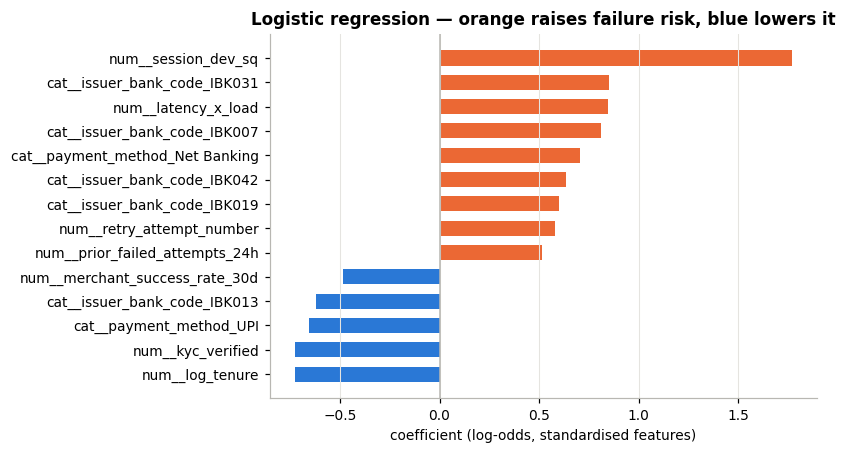

In [70]:
top = coef_df.head(14).sort_values("coefficient")
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.barh(top["feature"], top["coefficient"],
        color=[ORANGE if c > 0 else BLUE for c in top["coefficient"]], height=0.62)
ax.axvline(0, color="#b8b7b2", linewidth=1)
ax.set_xlabel("coefficient (log-odds, standardised features)")
ax.set_title("Logistic regression — orange raises failure risk, blue lowers it")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

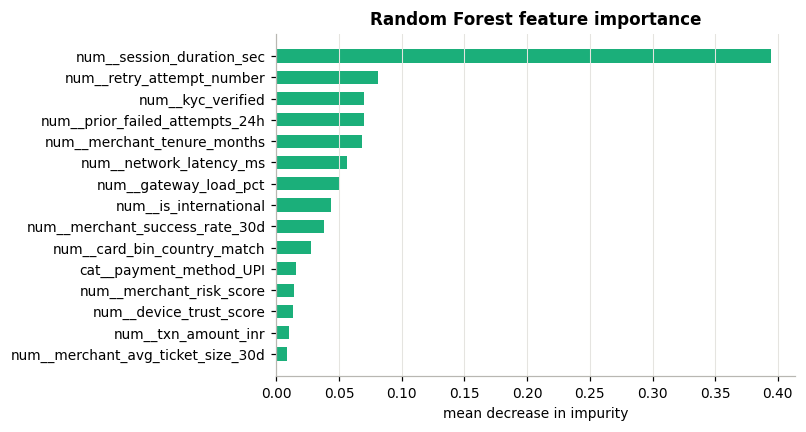

In [71]:
# --- Random Forest impurity importances ------------------------------------------------
rf_names = rf_final.named_steps["prep"].get_feature_names_out()
rf_imp = (pd.DataFrame({"feature": rf_names,
                        "importance": rf_final.named_steps["model"].feature_importances_})
            .sort_values("importance", ascending=False).head(15))

fig, ax = plt.subplots(figsize=(7.4, 4.0))
d = rf_imp.sort_values("importance")
ax.barh(d["feature"], d["importance"], color=AQUA, height=0.62)
ax.set_xlabel("mean decrease in impurity")
ax.set_title("Random Forest feature importance")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

In [72]:
# --- Permutation importance: model-agnostic, and it measures what we actually care about
from sklearn.inspection import permutation_importance

perm_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_test_eng), 6000, replace=False)
perm = permutation_importance(
    logit_final, X_test_eng.iloc[perm_idx], y_test.iloc[perm_idx],
    n_repeats=5, random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=1)

pi = (pd.DataFrame({"feature": X_test_eng.columns,
                    "drop_in_AUC": perm.importances_mean,
                    "std": perm.importances_std})
        .sort_values("drop_in_AUC", ascending=False).head(12))
print(pi.round(4).to_string(index=False))

                  feature  drop_in_AUC    std
           session_dev_sq       0.1910 0.0036
           latency_x_load       0.0458 0.0009
             kyc_verified       0.0274 0.0017
               log_tenure       0.0265 0.0015
     retry_attempt_number       0.0205 0.0013
prior_failed_attempts_24h       0.0168 0.0014
merchant_success_rate_30d       0.0099 0.0014
           payment_method       0.0092 0.0005
         is_international       0.0086 0.0009
   card_bin_country_match       0.0049 0.0015
         issuer_bank_code       0.0046 0.0005
       device_trust_score       0.0027 0.0004


### Reading the three views together

The three views agree on the substance, and where they disagree is the most useful part.

**The coefficient table found the planted signal exactly — and that is a trap.** Five
`issuer_bank_code` dummies (IBK031, IBK007, IBK042, IBK019 raising risk, IBK013 lowering
it) sit in the top 15, with odds ratios above 2. Those are real: a handful of issuers
genuinely are worse. But **permutation importance ranks `issuer_bank_code` near the
bottom, at 0.005 AUC.** Both are correct, and the reconciliation is the lesson:

> **A large coefficient is not a large contribution.** Each of those banks carries about
> 2.2% of traffic, so a big per-unit effect on 2% of rows moves the overall ranking very
> little. Standardising a sparse one-hot column makes this worse — a rare dummy has small
> variance, so dividing by it inflates the coefficient's scale. Read coefficients for
> *direction and mechanism*, and permutation importance for *how much it matters*.

**Permutation importance is the most trustworthy of the three** for the "how much" question,
because it measures exactly that — how much test AUC is lost if this feature's information
is destroyed — and it is model-agnostic. `session_dev_sq` costs **0.191** when shuffled,
roughly **4× the next feature** and about 40× the issuer column, confirming the EDA finding
end to end. Its weakness is correlated features: shuffling one of a correlated pair leaves
the model leaning on the other, so both look unimportant. Dropping
`merchant_gmv_per_txn_30d` in 4.4 is part of why this ranking is readable.

**The Random Forest's impurity importances are led by `session_duration_sec` itself** —
even though the forest was never given the squared term. That is direct evidence that it
found the U-shape through recursive splits, which is the whole reason it beat the raw
logistic model. Worth knowing about this measure: impurity importance is biased toward
high-cardinality and continuous features, because those offer more candidate split points.
Notice that the bias runs *against* the issuer dummies here — a binary one-hot column
offers exactly one split point, so no `issuer_bank_code` dummy reaches the top 15 at all.

And all three are **associational, not causal**. "Sessions far from 90s fail more" does not
license "force sessions to 90s". Only the experiment in Section 6 supports a causal claim,
and only about the one thing it randomised.


---

# 11. Stretch goal — regressing `revenue_loss_inr`

`revenue_loss_inr` is populated only for failed transactions. Predicting it lets the
routing logic weight by *expected value lost* rather than probability alone: a ₹40,000
travel booking at 20% risk deserves more effort than a ₹80 recharge at 40%.

Modelling it only on failures means the deployed system is **two-stage** — P(fail) from
Section 10, then E[loss | fail] here — and the product of the two is expected loss.


In [73]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             median_absolute_error)

failed = df[df["revenue_loss_inr"] > 0].copy()
print(f"failed transactions: {len(failed):,}")
print(failed["revenue_loss_inr"].describe().round(1).to_string())
print(f"\nskewness : {failed['revenue_loss_inr'].skew():.2f}")
print(f"kurtosis : {failed['revenue_loss_inr'].kurtosis():.2f}")
print(f"mean Rs {failed['revenue_loss_inr'].mean():,.0f} vs median Rs {failed['revenue_loss_inr'].median():,.0f}"
      "  <- mean >> median is the signature of a right-skewed target")

failed transactions: 31,916
count    31916.0
mean       450.7
std        631.1
min          3.6
25%        130.9
50%        260.7
75%        528.6
max      25147.3

skewness : 6.73
kurtosis : 116.55
mean Rs 451 vs median Rs 261  <- mean >> median is the signature of a right-skewed target


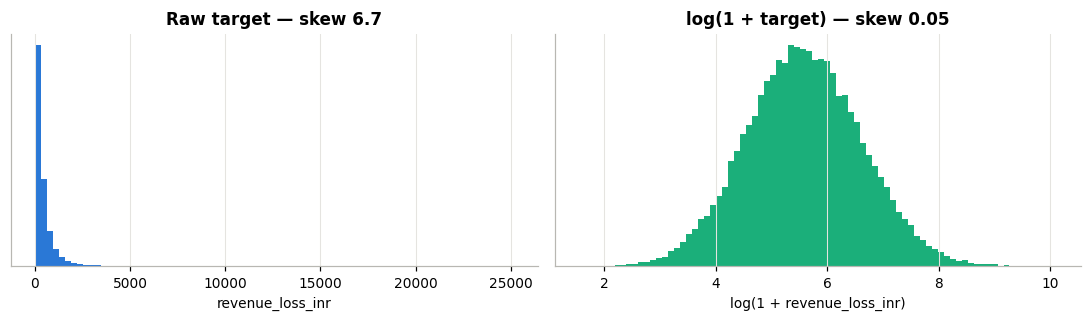

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.0))
axes[0].hist(failed["revenue_loss_inr"], bins=80, color=BLUE, edgecolor="none")
axes[0].set_title(f"Raw target — skew {failed['revenue_loss_inr'].skew():.1f}")
axes[0].set_xlabel("revenue_loss_inr"); axes[0].set_yticks([])

axes[1].hist(np.log1p(failed["revenue_loss_inr"]), bins=80, color=AQUA, edgecolor="none")
axes[1].set_title(f"log(1 + target) — skew {np.log1p(failed['revenue_loss_inr']).skew():.2f}")
axes[1].set_xlabel("log(1 + revenue_loss_inr)"); axes[1].set_yticks([])
plt.tight_layout(); plt.show()

The raw target is strongly right-skewed (skew ≈ 6.7, kurtosis ≈ 117); `log(1 + loss)` is
close to symmetric. That matters because **ordinary least squares assumes the errors are
roughly normal and homoscedastic** — constant variance across the range of the prediction.
On a skewed target neither holds: the residual spread grows with the fitted value, and the
few enormous losses get outsized leverage because the loss function is *squared*. I test
that claim rather than assert it.


In [75]:
Xr = failed.drop(columns=["txn_id", "merchant_id", "txn_timestamp",
                          "revenue_loss_inr", "payment_failed"])
yr = failed["revenue_loss_inr"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.2, random_state=RANDOM_STATE)

num_r = Xr_train.select_dtypes(include="number").columns.tolist()
cat_r = [c for c in Xr_train.columns if c not in num_r]

prep_r_lin = ColumnTransformer([
    ("num", Pipeline([("i", SimpleImputer(strategy="median")), ("s", StandardScaler())]), num_r),
    ("cat", Pipeline([("i", SimpleImputer(strategy="most_frequent")),
                      ("o", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_r),
])
prep_r_tree = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_r),
    ("cat", Pipeline([("i", SimpleImputer(strategy="most_frequent")),
                      ("o", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_r),
])

# A rupee loss can never exceed the largest loss ever observed in training; capping the
# back-transformed predictions is a business constraint, not a metric trick.
LOSS_CAP = yr_train.max()
print(f"prediction cap (max training loss): Rs {LOSS_CAP:,.0f}")

def reg_report(name, y_true, y_pred):
    return {"model": name,
            "MAE_Rs": mean_absolute_error(y_true, y_pred),
            "MedAE_Rs": median_absolute_error(y_true, y_pred),
            "RMSE_Rs": np.sqrt(mean_squared_error(y_true, y_pred)),
            "R2_on_log": r2_score(np.log1p(y_true), np.log1p(np.clip(y_pred, 0, None)))}

reg_results = []

prediction cap (max training loss): Rs 25,147


In [76]:
# (1) OLS on the raw, skewed target
m_raw = Pipeline([("prep", prep_r_lin), ("m", LinearRegression())]).fit(Xr_train, yr_train)
pred_raw = m_raw.predict(Xr_test)
reg_results.append(reg_report("OLS on raw target", yr_test, pred_raw))

# (2) Ridge on log(1+y), back-transformed and capped
m_log = Pipeline([("prep", prep_r_lin), ("m", Ridge(alpha=1.0))]).fit(Xr_train, np.log1p(yr_train))
log_fit = m_log.predict(Xr_test)
pred_log = np.clip(np.expm1(log_fit), 0, LOSS_CAP)
reg_results.append(reg_report("Ridge on log target", yr_test, pred_log))

# Heteroscedasticity check: does the size of the error grow with the prediction?
res_raw = yr_test.values - pred_raw
res_log = np.log1p(yr_test.values) - log_fit
print(f"corr(|residual|, fitted) on the RAW scale : {np.corrcoef(np.abs(res_raw), pred_raw)[0,1]:.3f}")
print(f"corr(|residual|, fitted) on the LOG scale : {np.corrcoef(np.abs(res_log), log_fit)[0,1]:.3f}")
print("-> the log model's errors are far closer to constant-variance")

corr(|residual|, fitted) on the RAW scale : 0.418
corr(|residual|, fitted) on the LOG scale : 0.090
-> the log model's errors are far closer to constant-variance


In [77]:
# (3) Duan's smearing correction - back-transforming exp() returns the conditional
#     MEDIAN, not the mean. This factor re-targets the mean.
smear = np.mean(np.exp(np.log1p(yr_train) - m_log.predict(Xr_train)))
print(f"smearing factor = {smear:.4f}")
reg_results.append(reg_report("Ridge on log + smearing", yr_test,
                              np.clip(pred_log * smear, 0, LOSS_CAP)))

# (4) Tree ensemble on the raw target - no transform needed at all
m_rf = Pipeline([("prep", prep_r_tree),
                 ("m", RandomForestRegressor(n_estimators=200, min_samples_leaf=20,
                                             n_jobs=-1, random_state=RANDOM_STATE))]).fit(Xr_train, yr_train)
reg_results.append(reg_report("Random Forest on raw target", yr_test, m_rf.predict(Xr_test)))

# (5) Tree ensemble on the log target
m_rf_log = Pipeline([("prep", prep_r_tree),
                     ("m", RandomForestRegressor(n_estimators=200, min_samples_leaf=20,
                                                 n_jobs=-1, random_state=RANDOM_STATE))]).fit(Xr_train, np.log1p(yr_train))
reg_results.append(reg_report("Random Forest on log target", yr_test,
                              np.clip(np.expm1(m_rf_log.predict(Xr_test)), 0, LOSS_CAP)))

pd.DataFrame(reg_results).round(2)

smearing factor = 1.5005


,model,MAE_Rs,MedAE_Rs,RMSE_Rs,R2_on_log
0,OLS on raw target,300.42,196.44,532.91,0.13
1,Ridge on log target,312.55,132.06,956.50,0.22
2,Ridge on log + smearing,343.94,198.88,1001.75,0.07
3,Random Forest on raw target,299.19,187.01,534.74,0.19
4,Random Forest on log target,272.31,130.62,557.55,0.31


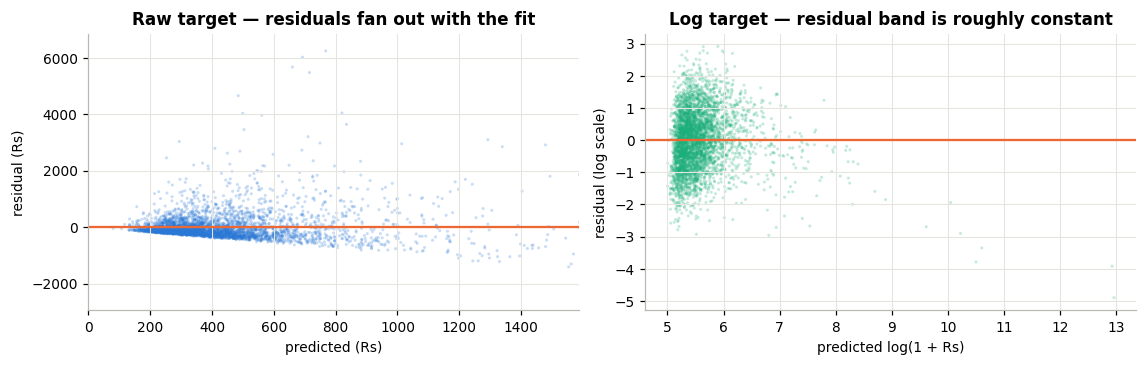

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4))
s = np.random.RandomState(0).choice(len(yr_test), 4000, replace=False)

axes[0].scatter(pred_raw[s], res_raw[s], s=4, alpha=0.25, color=BLUE, edgecolors="none")
axes[0].axhline(0, color=ORANGE, linewidth=1.5)
axes[0].set_xlabel("predicted (Rs)"); axes[0].set_ylabel("residual (Rs)")
axes[0].set_title("Raw target — residuals fan out with the fit")
axes[0].set_xlim(0, np.percentile(pred_raw, 99))

axes[1].scatter(log_fit[s], res_log[s], s=4, alpha=0.25, color=AQUA, edgecolors="none")
axes[1].axhline(0, color=ORANGE, linewidth=1.5)
axes[1].set_xlabel("predicted log(1 + Rs)"); axes[1].set_ylabel("residual (log scale)")
axes[1].set_title("Log target — residual band is roughly constant")
plt.tight_layout(); plt.show()

### What the regression actually shows

The result is more nuanced than "log-transform your skewed target and win", and the
nuance is the interesting part:

- **The log transform fixes the residual structure, decisively.** The correlation between
  the absolute residual and the fitted value falls from ~0.42 on the raw scale to ~0.09 on
  the log scale. Heteroscedasticity is what invalidates OLS standard errors and confidence
  intervals, so if the model is being used for *inference* rather than pure prediction, the
  log model is the only defensible one.
- **It also cuts the median error by a third** (MedAE ₹196 → ₹132) and lifts R² on the log
  scale from 0.13 to 0.22. On a typical transaction it is clearly the better model.
- **But its RMSE is much worse**, because `exp()` amplifies: a modest error in log space
  becomes an enormous error in rupees for the handful of transactions the model places
  high in the tail. Capping predictions at the largest loss ever observed contains this,
  but does not remove it. **Whether the log transform "wins" depends entirely on which
  error you are paid to minimise** — typical error, or worst-case error.
- **Duan's smearing correction makes MAE and MedAE worse here**, and that is not a
  contradiction. Smearing exists to re-target the conditional *mean* after
  back-transformation; MAE and MedAE reward predicting the conditional *median*. Applying a
  mean correction and then grading on a median metric is a mismatch. It would be the right
  call if I needed unbiased rupee totals (for a revenue forecast) rather than good
  per-transaction predictions.
- **The Random Forest needs no transform to function** — splits are invariant to monotone
  transforms of the target's ordering. It still improves on the log target because its
  split criterion is variance reduction, and squared error on a skewed target chases the
  few enormous values.

**Pick:** the **Random Forest on the log target** — best MAE, best MedAE, best R² on the
log scale, and an RMSE close to the raw-target models. If the routing logic needs to be
risk-averse rather than accurate on average, I would replace it with a **quantile
regressor** predicting the 80th percentile of loss, since in a cost-asymmetric setting
under-predicting a large loss is worse than over-predicting a small one.


---

# 12. Recommendation

## Which model would I ship?

**Logistic regression with the four engineered terms**, at a decision threshold of about
**0.28** rather than 0.5.

This is a close call and I want to be straight about it: **XGBoost is genuinely the more
accurate model** — roughly +0.005 ROC-AUC and +0.015 PR-AUC. The cost table in 10.2 puts
that difference in rupees at each model's own optimal threshold, and it is small. Against
that small, real accuracy loss:

| | Engineered logistic | XGBoost (tuned) |
|---|---|---|
| Test ROC-AUC / PR-AUC | 0.929 / 0.774 | **0.934 / 0.790** |
| Expected cost at optimal threshold | slightly higher | **lowest** |
| Inference | a dot product — microseconds | 300 trees traversed |
| Explaining a decline | signed coefficients, directly auditable | needs SHAP |
| Train/test AUC gap | **0.002** | 0.012 |
| Fits in the routing hot path | **yes** | needs a service hop |
| Monitoring | ~100 coefficients to watch | opaque; drift is harder to attribute |

A payment gateway scores inside the routing hot path, where milliseconds are money, and a
risk function that has to justify declines will ask for the coefficient table. For *this*
deployment those two constraints outweigh a fraction of a percent of PR-AUC. **If the
scoring call were asynchronous, or if the accuracy gap widened past a few percent of
expected cost, I would ship XGBoost instead** — and I would keep it trained and monitored
either way, because a widening gap is the cheapest available signal that new structure has
appeared in the data which my four hand-built terms no longer capture.

## What I would check before trusting this in production

**Before shipping**

1. **Confirm the leakage findings with the payments engineer.** I dropped three columns on
   reasoning about *when* they are written. That reasoning needs a human to confirm, and
   `merchant_success_rate_30d` needs an explicit check that its 30-day window is trailing,
   not recomputed over the full period after the fact.
2. **Re-validate on a time-based split.** Train on months 1–4, test on months 5–6. The
   monthly failure rate is flat so I expect agreement — but a random split cannot detect
   drift, and a production model lives in the future.
3. **Shadow-run for two weeks.** Score live traffic, act on nothing, compare the predicted
   failure-rate distribution against the offline test distribution. A gap means a feature
   is computed differently online than in the warehouse — the most common way a validated
   model fails in production, and one no amount of offline work catches.
4. **Verify feature availability and latency at the routing decision point.** Every feature
   must be computable within the routing budget. `gateway_load_pct` in particular has to be
   a live reading, not a warehouse aggregate.
5. **Fairness / segment review.** Check performance by region, merchant size and payment
   method. A model with strong overall AUC can still be much worse for small merchants —
   precisely the ones least able to absorb a failed payment.

**After shipping**

6. **Monitor input drift, not just accuracy.** Population Stability Index per feature,
   weekly. Labels arrive within seconds here, but on most problems drift shows up in the
   inputs long before it shows up in a metric.
7. **Watch calibration, not only ranking.** If routing weights by expected value, a
   drifting probability scale silently mis-prices decisions while AUC looks fine.
8. **Recompute the threshold quarterly.** The 0.28 optimum depends on ₹450 and ₹30. Those
   are business inputs and they change.
9. **Beware the feedback loop.** Once we reroute high-risk transactions they stop failing,
   so the next training set no longer contains the failures the model prevented — and it
   will gradually unlearn the very patterns that made it useful. The standard mitigation is
   a small **holdout** (1–2% of traffic routed as before) that keeps supplying unbiased
   labels. This is the most under-appreciated risk in any model that changes the process
   generating its own training data.

## Honest limitations

- The A/B result is causal **only** for the smart-retry routing change, at a 50/50 split,
  over this six-month window. It says nothing about what a full rollout does to shared
  acquirer capacity.
- The model is **predictive, not causal**. `session_dev_sq` having the largest coefficient
  does not mean forcing 90-second checkouts would reduce failures.
- Randomisation is per transaction, so repeated attempts from the same merchant are not
  independent; clustered standard errors would widen the confidence intervals somewhat.
- The engineered features encode two effects I found by looking. There are almost certainly
  others I did not — XGBoost's residual advantage is the cheapest standing test of that.
- KNN was evaluated on a 30,000-row subsample rather than the full training set. Its
  ranking below the tree models is consistent across every k I tried, but the numbers are
  not strictly comparable to the others.
